# Nifty 500 Quarterly Momentum: Top 7 by 3-Month Return (survivorship-free)

**Rule.** At the start of every quarter (Jan / Apr / Jul / Oct), take the stocks that were **in the Nifty 500 on that date**
and rank them by their return over the previous 3 months (63 trading days). Buy the **top 7 in equal weight**, hold for 3 months, then repeat.


**Assumptions:** the signal uses the close on the last trading day of the quarter and trades fill at the next day's close.
Costs are 0.25% per side. Eligibility requires a median daily traded value of at least ₹2 cr over the lookback.
A stock that stops trading while held is carried at its last traded price.

> **Headline:** once survivorship bias is removed, the strategy earns **7.8% CAGR against 12.2% for the Nifty 50 TR**.
> 6–12-month lookbacks with more names do beat the index (Section 11). See Section 12 for the full conclusions.


## 1. Config

In [1]:
CONFIG = dict(
    START            = "2016-01-01",   # first rebalance on/after this date
    LOOKBACK_DAYS    = 63,             # ~3 months of trading days
    SKIP_DAYS        = 0,              # 21 = skip the latest month
    TOP_N            = 7,
    REBAL_MONTHS     = (1, 4, 7, 10),
    COST_PER_SIDE    = 0.0025,
    MIN_MEDIAN_TV_CR = 2.0,            # ₹ crore, median daily traded value over the lookback
    RF_ANNUAL        = 0.065,
    ANCHOR_DATE      = "2026-09-23",   # date of data/ind_nifty500list.csv (membership is rolled back from here)
    N_RANDOM_SIMS    = 2000,
    SEED             = 42,
    DATA_DIR         = "data",
    CHART_DIR        = "charts",
)
CONFIG

{'START': '2016-01-01',
 'LOOKBACK_DAYS': 63,
 'SKIP_DAYS': 0,
 'TOP_N': 7,
 'REBAL_MONTHS': (1, 4, 7, 10),
 'COST_PER_SIDE': 0.0025,
 'MIN_MEDIAN_TV_CR': 2.0,
 'RF_ANNUAL': 0.065,
 'ANCHOR_DATE': '2026-09-23',
 'N_RANDOM_SIMS': 2000,
 'SEED': 42,
 'DATA_DIR': 'data',
 'CHART_DIR': 'charts'}

## 2. Setup

In [2]:
import os, re, glob, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 40, "display.max_colwidth", 120)
D = CONFIG["DATA_DIR"]; os.makedirs(CONFIG["CHART_DIR"], exist_ok=True)

COL = {"Momentum Top 7": "#2a78d6", "Nifty 50 TR": "#eb6834", "Nifty 50": "#eda100",
       "Nifty 500 TR": "#1baf7a", "EW Nifty 500 (PIT)": "#4a3aa7", "Survivor-biased": "#e87ba4"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
DIV = LinearSegmentedColormap.from_list("div", ["#c0392b", "#f2f1ee", "#2a78d6"])
SEQ = LinearSegmentedColormap.from_list("seq", ["#e8f0fb", "#2a78d6", "#0d2f5c"])
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK2, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.titlecolor": INK, "legend.frameon": False, "lines.linewidth": 2, "font.size": 10})
def save(fig, name): fig.savefig(f"{CONFIG['CHART_DIR']}/{name}.png", bbox_inches="tight", dpi=130)
pct = lambda x: f"{x:.1%}"

## 3. Point-in-time Nifty 500 membership

### 3.1 Parse NSE index-change press releases
NSE Indices announces every Nifty 500 change in a press release: the semi-annual reviews (Mar/Sep), plus ad-hoc replacements
for mergers, demergers and suspensions. The releases were downloaded as PDFs from `niftyindices.com/Press_Release/`,
converted to text and cached in `data/press_releases_txt/`.

For each release the parser:
1. finds the `NIFTY 500` section (called `CNX 500` before Nov-2015);
2. reads the *excluded* and *included* symbol tables;
3. takes the nearest "effective from …" date above the section.

A parsed symbol is kept only if it actually traded on NSE around the announcement date.

In [3]:
BH = pd.read_parquet(f"{D}/nse_bhav_equity.parquet")
for c in ["symbol", "series", "isin"]: BH[c] = BH[c].astype(str)
span = BH.groupby("symbol").date.agg(["min", "max"])

MONTHS = "January|February|March|April|May|June|July|August|September|October|November|December"
DATE = rf"({MONTHS})\s*(\d\s?\d?)\s*,\s*(\d{{3}}\s?\d)"
HDR  = re.compile(r"^\s*(?:\(?\d+\s*[\)\.]|[a-z]\))?\s*(?:NIFTY|CNX)\s*500\s*(?:index)?\s*:?\s*$", re.I | re.M)
NEXT = re.compile(r"^\s*\(?\d+\s*[\)\.]\s*[A-Za-z]|^\s*[A-Z]\.\s+[A-Z]|^\s*[a-z]\)\s*(?:NIFTY|CNX)|"
                  r"^\s*(?:NIFTY|CNX)\s*[\w &\-:]+\s*$|^\s*For more details|^\s*About NSE|^\s*Annexure", re.I | re.M)
EFF  = re.compile(r"(?:effective(?:\s*from)?|w\.?\s*e\.?\s*f\.?)[^0-9]{0,40}?(?:\w+day,?\s*)?" + DATE, re.I | re.S)

def parse_release(name, t):
    pdate = pd.Timestamp(pd.to_datetime(re.search(r"(\d{8})", name).group(1), format="%d%m%Y"))
    effs = [(m.start(), pd.to_datetime(f"{m.group(1)} {m.group(2).replace(' ', '')} {m.group(3).replace(' ', '')}",
                                        format="%B %d %Y")) for m in EFF.finditer(t)]
    rows = []
    for h in HDR.finditer(t):
        before = [e for p, e in effs if p < h.start()]
        eff = before[-1] if before else (effs[0][1] if effs else pdate)
        rest = t[h.end():]; nx = NEXT.search(rest); sec = rest[:nx.start()] if nx else rest[:6000]
        mode = None
        for line in sec.splitlines():
            l = line.strip()
            if re.search(r"(follow|being|are|is)\b.*exclu", l, re.I): mode = "OUT"; continue
            if re.search(r"(follow|being|are|is)\b.*inclu", l, re.I): mode = "IN"; continue
            mm = re.match(r"^(?:.*\s)?([A-Z0-9][A-Z0-9&\-]{1,19})\s*$", l)
            if mode and mm and not mm.group(1).isdigit() and not re.match(r"^(Sr|No)\b", l):
                s = mm.group(1)
                ok = s in span.index and span.loc[s, "min"] <= pdate + pd.Timedelta(days=60) \
                     and span.loc[s, "max"] >= pdate - pd.Timedelta(days=400)
                if ok: rows.append(dict(release=name, published=pdate, effective=eff, action=mode, symbol=s))
    return rows

rows = []
for f in sorted(glob.glob(f"{D}/press_releases_txt/*.txt")):
    rows += parse_release(os.path.basename(f)[:-4], open(f).read())
CH = pd.DataFrame(rows).drop_duplicates(["release", "action", "symbol"])

# Manual corrections: releases whose layout the table parser cannot read
CH = CH[~((CH.release == "ind_prs23082024") & (CH.symbol == "IDEA"))]          # IDEA exclusion revoked on 25-Sep-2024 ...
MANUAL = pd.DataFrame([
    dict(release="ind_prs25092024",   published="2024-09-25", effective="2024-09-30", action="OUT", symbol="PRSMJOHNSN",
         note="... Prism Johnson excluded instead (revocation notice, free-text table)"),
    dict(release="ind_prs23082024_1", published="2024-08-23", effective="2024-08-30", action="OUT", symbol="TATAMTRDVR",
         note="Tata Motors DVR shares cancelled; removed with no replacement (index goes 501 → 500)")])
MANUAL[["published", "effective"]] = MANUAL[["published", "effective"]].apply(pd.to_datetime)
display(Markdown("**Manual corrections**")); display(MANUAL.style.hide(axis="index"))
CH = pd.concat([CH, MANUAL.drop(columns="note")], ignore_index=True)
CH = CH[CH.effective <= pd.Timestamp(CONFIG["ANCHOR_DATE"])]   # changes announced but not yet effective are ignored
summary = CH.groupby("release").agg(effective=("effective", "first"), IN=("action", lambda a: (a == "IN").sum()),
                                    OUT=("action", lambda a: (a == "OUT").sum())).sort_values("effective")
print(f"{len(CH)} change rows from {summary.shape[0]} releases, "
      f"{summary.effective.min().date()} → {summary.effective.max().date()}")
display(summary[summary.IN + summary.OUT >= 15].rename(columns={"effective": "effective (semi-annual reviews)"}))

**Manual corrections**

release,published,effective,action,symbol,note
ind_prs25092024,2024-09-25 00:00:00,2024-09-30 00:00:00,OUT,PRSMJOHNSN,"... Prism Johnson excluded instead (revocation notice, free-text table)"
ind_prs23082024_1,2024-08-23 00:00:00,2024-08-30 00:00:00,OUT,TATAMTRDVR,Tata Motors DVR shares cancelled; removed with no replacement (index goes 501 → 500)


1439 change rows from 90 releases, 2015-02-02 → 2026-07-17


,effective (semi-annual reviews),IN,OUT
release,,,
ind_prs20022015,2015-03-27,12,11
ind_prs12082015,2015-09-28,14,14
ind_prs22022016_2,2016-04-01,76,75
ind_prs12082016,2016-09-30,25,25
ind_prs16022017,2017-03-31,25,25
ind_prs28082017,2017-09-29,25,25
ind_prs21022018,2018-04-02,25,25
ind_prs28082018,2018-09-28,25,25
ind_prs25022019,2019-03-29,25,25


### 3.2 Roll the membership back from today's list
Start from today's constituent list (`ind_nifty500list.csv`) and walk backwards through the change log. At each effective date,
remove the names that were **included** and add back the names that were **excluded**. Symbols are normalised through NSE's
symbol-change file (e.g. ZOMATO → ETERNAL), plus three renames that file is missing. The result is a table of membership intervals.

In [4]:
sc = pd.read_csv(f"{D}/symbolchange.csv", header=None, names=["co", "old", "new", "date"], skipinitialspace=True)
sc["old"], sc["new"] = sc.old.str.strip(), sc.new.str.strip()
sc["date"] = pd.to_datetime(sc.date.str.strip(), format="%d-%b-%Y", errors="coerce")
sc = sc[sc.date >= "2013-01-01"][["old", "new", "date"]]
sc = pd.concat([sc, pd.DataFrame([("PHILIPCARB", "PCBL", "2022-02-01"), ("WABCOINDIA", "ZFCVINDIA", "2022-06-01"),
                                  ("BURGERKING", "RBA", "2022-03-01")], columns=["old", "new", "date"])
                .assign(date=lambda x: pd.to_datetime(x.date))]).sort_values("date")
REN = dict(zip(sc.old, sc.new))
def canon(s):
    for _ in range(10):
        if s not in REN: break
        s = REN[s]
    return s

CH["c"] = CH.symbol.map(canon)
ANCHOR = pd.Timestamp(CONFIG["ANCHOR_DATE"])
current = {canon(s) for s in pd.read_csv(f"{D}/ind_nifty500list.csv").Symbol if not s.startswith("DUMMY")}

def membership_intervals(anchor_set, anchor_date):
    s, open_end, out = set(anchor_set), {x: pd.Timestamp("2100-01-01") for x in anchor_set}, []
    for eff, g in CH[CH.effective <= anchor_date].sort_values("effective", ascending=False).groupby("effective", sort=False):
        for x in set(g[g.action == "IN"].c) & s:  out.append((x, eff, open_end.pop(x))); s.discard(x)
        for x in set(g[g.action == "OUT"].c) - s: s.add(x); open_end[x] = eff
    out += [(x, pd.Timestamp("2000-01-01"), open_end[x]) for x in s]
    return pd.DataFrame(out, columns=["symbol", "start", "end"])

IV = membership_intervals(current, ANCHOR)
def members(d):
    d = pd.Timestamp(d); return set(IV.symbol[(IV.start <= d) & (IV.end > d)])
print(f"{IV.symbol.nunique()} distinct companies have been in the Nifty 500 at some point since the log begins")

960 distinct companies have been in the Nifty 500 at some point since the log begins


### 3.3 Validation against archived constituent lists
**None of these lists were used to build the membership.** They're Wayback Machine captures of NSE's own `ind_nifty500list.csv`
(and `ind_cnx500list.csv` for 2015). If the change log is complete and parsed correctly, the rolled-back membership should match each one.

In [5]:
val = []
for f in sorted(glob.glob(f"{D}/n500_snapshots/*.csv")):
    d = pd.Timestamp(os.path.basename(f)[:8])
    snap = {canon(s.strip()) for s in pd.read_csv(f).Symbol if not s.strip().startswith("DUMMY")}
    rec = members(d)
    val.append(dict(snapshot=d.date(), snapshot_size=len(snap), rebuilt_size=len(rec), matched=len(rec & snap),
                    match_rate=len(rec & snap) / len(snap), only_in_rebuilt=", ".join(sorted(rec - snap)),
                    only_in_snapshot=", ".join(sorted(snap - rec))))
VAL = pd.DataFrame(val)
display(VAL.style.format({"match_rate": "{:.2%}"}).hide(axis="index"))
print(f"Overall: {VAL.matched.sum():,} of {VAL.snapshot_size.sum():,} snapshot constituents reproduced "
      f"({VAL.matched.sum() / VAL.snapshot_size.sum():.2%})")

snapshot,snapshot_size,rebuilt_size,matched,match_rate,only_in_rebuilt,only_in_snapshot
2015-03-25,500,499,499,99.80%,,IL&FSENGG
2018-10-04,501,501,501,100.00%,,
2019-02-01,501,501,501,100.00%,,
2020-07-25,501,501,501,100.00%,,
2022-05-04,501,501,500,99.80%,GMRAIRPORT,AARTIIND
2022-10-09,501,501,501,100.00%,,
2023-04-04,501,501,501,100.00%,,
2024-02-07,501,501,501,100.00%,,
2024-02-26,501,501,501,100.00%,,
2025-06-16,500,500,500,100.00%,,


Overall: 7,506 of 7,508 snapshot constituents reproduced (99.97%)


The rebuild matches every archived list from 2018 onward exactly. The two small misses have known causes:
* **2022-05-04:** the snapshot was captured on the morning a change took effect (GMR Infra in, Aarti Industries out), before NSE updated the file.
* **2015-03-25:** one name (IL&FS Engineering) is missing, which comes from a single ambiguous 2015 release.

Between 2015 and 2018 there are no snapshots. The 2015 match is still meaningful: to reproduce that list, the rollback has to pass through **every** release from 2015 to 2026.

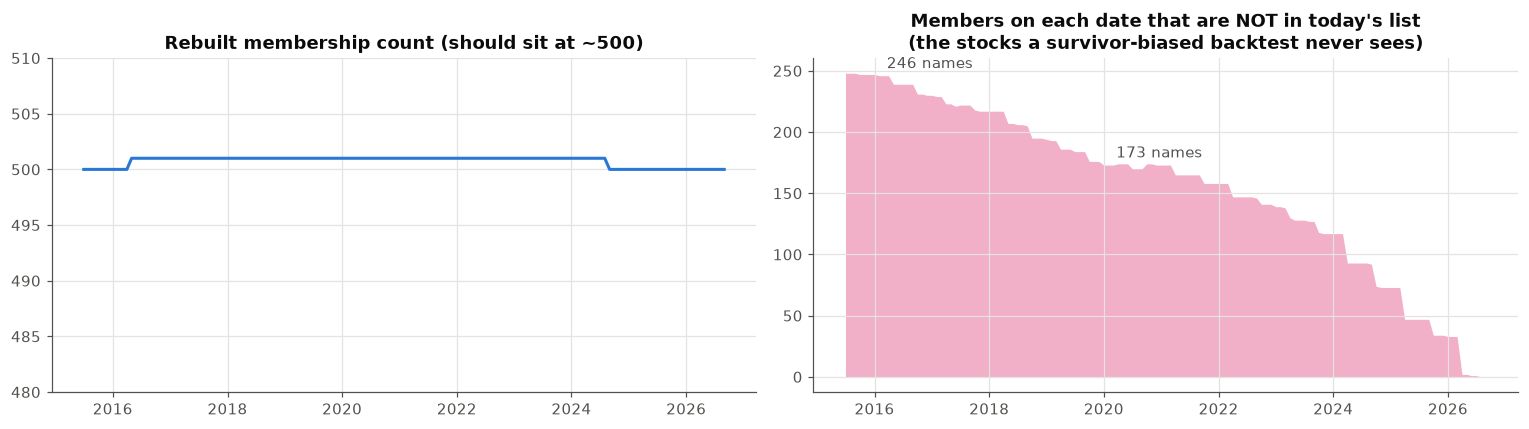

In [6]:
mdates = pd.date_range("2015-06-30", ANCHOR, freq="ME")
size = pd.Series({d: len(members(d)) for d in mdates})
ghost = pd.Series({d: len(members(d) - current) for d in mdates})
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(size.index, size, color=COL["Momentum Top 7"]); ax[0].set_ylim(480, 510)
ax[0].set_title("Rebuilt membership count (should sit at ~500)")
ax[1].fill_between(ghost.index, ghost, color=COL["Survivor-biased"], alpha=0.6, lw=0)
ax[1].set_title("Members on each date that are NOT in today's list\n(the stocks a survivor-biased backtest never sees)")
for d in ["2016-01-31", "2020-01-31"]:
    ax[1].annotate(f"{ghost.asof(pd.Timestamp(d))} names", (pd.Timestamp(d), ghost.asof(pd.Timestamp(d))),
                   xytext=(5, 5), textcoords="offset points", color=INK2)
plt.tight_layout(); save(fig, "01_membership"); plt.show()

## 4. Survivorship-free prices from NSE bhavcopies
The bhavcopy (NSE's daily closing-price file) lists every traded equity, including companies that later delisted, merged or went bust.
Its `PREVCLOSE` column is **not** adjusted for corporate actions, so a total-return series has to be built here.
Corporate actions come from NSE's corporate-actions API (`data/nse_corporate_actions.csv`, about 28k events). The adjustment factor
for each event, applied to the previous close on its ex-date:

| Event | Factor |
|---|---|
| Split (FV *a* → *b*) | *b / a* |
| Bonus *A:B* | *B / (A+B)* |
| Rights *A:B* at price *R* | TERP / prev close |
| Demerger / scheme of arrangement / capital reduction | open / prev close (the parent's price from NSE's special pre-open session) |
| Dividend *d* | 1 − *d* / prev close (total-return series only) |

NSE's listed ex-date is sometimes 1–3 days away from the day the price actually adjusts. Each split or bonus is therefore moved to the nearby
day whose opening gap best matches its ratio. Any remaining opening gap below −30% or above +45% is treated as an unrecorded corporate
action and neutralised at the open. A genuine crash opens near the previous close and falls during the day, so it isn't affected.

In [7]:
BH["canon"] = BH.symbol
for _ in range(4):   # date-aware: a row uses the new name only if dated before the rename
    m = BH[["canon", "date"]].merge(sc, left_on="canon", right_on="old", how="left")
    hit = (m.new.notna() & (m.date_x < m.date_y + pd.Timedelta(days=3))).values
    if not hit.any(): break
    BH.loc[hit, "canon"] = m.new.values[hit]
BH["pri"] = BH.series.map({"EQ": 0, "BE": 1, "BZ": 2})
BH = BH.sort_values(["canon", "date", "pri"]).drop_duplicates(["canon", "date"])
BH["prev"] = BH.groupby("canon").close.shift()

CA = pd.read_csv(f"{D}/nse_corporate_actions.csv")
CA["exDate"] = pd.to_datetime(CA.exDate, format="%d-%b-%Y", errors="coerce")
CA["subj"] = CA.subject.fillna("").str.strip(); CA["faceVal"] = pd.to_numeric(CA.faceVal, errors="coerce")
CA = CA.dropna(subset=["exDate"]).drop_duplicates(["symbol", "exDate", "subj"])
def classify(s):
    l = s.lower()
    if re.search(r"bonus\s*(deb|ncrp|pref)", l): return "other"
    if re.search(r"split|splt|sub-division|sub division", l): return "split"
    if "bonus" in l: return "bonus"
    if "right" in l: return "rights"
    if re.search(r"demerg|arrangement|amalgamation|capital reduction|consolidation|cash-out|reclass", l): return "other"
    if "div" in l: return "div"
CA["kind"] = CA.subj.map(classify); CA = CA[CA.kind.notna()]
NUM = r"(?:rs|re)\.?\s*([\d]+(?:\.\d+)?)"

rows_ = BH[["canon", "symbol", "isin", "date", "open", "close", "prev"]]
ex = CA[["symbol", "isin", "exDate", "kind", "subj", "faceVal"]]
a = rows_.merge(ex, left_on=["symbol", "date"], right_on=["symbol", "exDate"])
got = set(zip(a.symbol, a.exDate, a.subj))
miss = ex[[(s, d, j) not in got for s, d, j in zip(ex.symbol, ex.exDate, ex.subj)]]
b = pd.merge_asof(miss.sort_values("exDate"), rows_.sort_values("date"), left_on="exDate", right_on="date", by="isin",
                  direction="forward", tolerance=pd.Timedelta(days=7)).dropna(subset=["date"])
b = b.rename(columns={"symbol_x": "symbol"})
E = pd.concat([a, b], ignore_index=True).drop_duplicates(["canon", "date", "subj"])

def factor(r):
    p, l = r.prev, r.subj.lower()
    if not (p > 0): return np.nan
    if r.kind == "div":
        d = sum(float(x) for x in re.findall(NUM, l)); return 1 - d / p if 0 < d < 0.5 * p else 1.0
    if r.kind == "split":
        x = re.findall(NUM, l); return float(x[1]) / float(x[0]) if len(x) >= 2 and float(x[0]) > 0 else r.open / p
    if r.kind == "bonus":
        m = re.search(r"bonus\s*(\d+)\s*:\s*(\d+)", l); return int(m.group(2)) / (int(m.group(1)) + int(m.group(2))) if m else r.open / p
    if r.kind == "rights":
        m = re.search(r"rights?\s*(\d+)\s*:\s*(\d+).*?premium\s*(?:of\s*)?(?:rs|re)\.?\s*([\d.]+)", l)
        if m:
            A, B, R = int(m.group(1)), int(m.group(2)), (r.faceVal if r.faceVal == r.faceVal else 10) + float(m.group(3))
            if R < p: return (B * p + A * R) / (A + B) / p
        return 1.0
    return r.open / p if r.open > 0 else np.nan
E["f"] = E.apply(factor, axis=1); E = E.dropna(subset=["f"])

G = BH[["canon", "date", "open", "prev"]].assign(gap=lambda x: np.log(x.open / x.prev)).set_index("canon")
def align(r):
    if r.kind in ("div", "rights") or r.canon not in G.index: return r.date
    w = G.loc[[r.canon]]
    w = w[(w.date >= r.date - pd.Timedelta(days=6)) & (w.date <= r.date + pd.Timedelta(days=6))].dropna(subset=["gap"]).reset_index(drop=True)
    if w.empty: return r.date
    if r.kind in ("split", "bonus"):
        dist = (w.gap - np.log(r.f)).abs(); return w.date.iloc[dist.idxmin()] if dist.min() < 0.12 else r.date
    return w.date.iloc[w.gap.abs().idxmax()]
E["date_aligned"] = E.apply(align, axis=1)
gap_at = G.reset_index().set_index(["canon", "date"]).gap
oth = E.kind == "other"
E.loc[oth, "f"] = [float(np.exp(gap_at.get((c, d), 0.0))) for c, d in zip(E.loc[oth, "canon"], E.loc[oth, "date_aligned"])]
E = E.drop_duplicates(["canon", "date_aligned", "kind", "f"])

f_nd = E[E.kind != "div"].groupby(["canon", "date_aligned"]).f.prod().rename("f_nd")
f_dv = E[E.kind == "div"].groupby(["canon", "date_aligned"]).f.prod().rename("f_dv")
BH = BH.merge(f_nd, left_on=["canon", "date"], right_index=True, how="left").merge(f_dv, left_on=["canon", "date"], right_index=True, how="left")
BH[["f_nd", "f_dv"]] = BH[["f_nd", "f_dv"]].fillna(1.0)
g = BH.open / (BH.prev * BH.f_nd)
BH["gap_fix"] = np.where((g < 0.70) | (g > 1.45), g, 1.0); BH["f_nd"] *= BH.gap_fix
BH["ret_tr"] = BH.close / (BH.prev * BH.f_nd * BH.f_dv) - 1
BH["ret_px"] = BH.close / (BH.prev * BH.f_nd) - 1

display(E.kind.value_counts().rename("events applied").to_frame().T)
print(f"Residual opening gaps neutralised (all stocks): {(BH.gap_fix != 1).sum():,}")

kind,div,bonus,split,rights,other
events applied,16258,453,448,294,154


Residual opening gaps neutralised (all stocks): 2,095


In [8]:
# wide panels for every company that was ever a member (plus today's list for the biased comparison)
EVER = set(IV.symbol[IV.end > "2015-01-01"]) | current
B = BH[BH.canon.isin(EVER)]
CAL = pd.DatetimeIndex(sorted(BH.date.unique()))
RET = B.pivot(index="date", columns="canon", values="ret_tr").reindex(CAL)
RETPX = B.pivot(index="date", columns="canon", values="ret_px").reindex(CAL)
TRADED = RET.notna()
TRI = (1 + RET.fillna(0)).cumprod().where(TRADED.cumsum() > 0)          # total-return index, NaN before listing
TV = B.pivot(index="date", columns="canon", values="value").reindex(CAL) / 1e7   # ₹ crore
LAST_TRADE = TRADED[::-1].idxmax()
print(f"Price panel: {TRI.shape[1]} companies × {TRI.shape[0]} days  |  "
      f"members with no price data: {sorted(EVER - set(TRI.columns)) or 'none'}")

# ghost check: large moves while a member (should only be genuine market events)
mem_mask = pd.DataFrame(False, index=CAL, columns=RET.columns)
for s, st, en in IV[IV.symbol.isin(RET.columns)].itertuples(index=False):
    mem_mask.loc[(CAL >= st) & (CAL < en), s] = True
big = RET.where(mem_mask & ((RET > 0.35) | (RET < -0.30))).stack().dropna().rename("1-day TR").reset_index()
big.columns = ["date", "symbol", "1-day TR"]
display(Markdown(f"**Remaining 1-day moves beyond −30% / +35% while in the index ({len(big)}).** "
                 "All are genuine events, e.g. the YES Bank, DHFL, Jet Airways and Infibeam collapses, "
                 "the Oct-2017 PSU-bank recapitalisation and the Mar-2020 rebound:"))
display(big.sort_values("1-day TR").head(12).style.format({"1-day TR": "{:+.0%}", "date": lambda d: d.strftime("%Y-%m-%d")}).hide(axis="index"))

Price panel: 960 companies × 3149 days  |  members with no price data: none


**Remaining 1-day moves beyond −30% / +35% while in the index (34).** All are genuine events, e.g. the YES Bank, DHFL, Jet Airways and Infibeam collapses, the Oct-2017 PSU-bank recapitalisation and the Mar-2020 rebound:

date,symbol,1-day TR
2018-09-28,CCAVENUE,-71%
2020-03-06,YESBANK,-56%
2018-09-21,DHFL,-43%
2019-06-18,JETAIRWAYS,-41%
2015-06-03,UNITECH,-36%
2020-03-18,IDEA,-35%
2015-09-03,AMTEKAUTO,-35%
2019-02-04,RCOM,-35%
2019-02-04,RPOWER,-35%
2019-09-30,SAMMAANCAP,-34%


### 4.1 Price validation
Two checks:
1. **Against Yahoo** for large, continuously listed stocks, where Yahoo's adjusted close is reliable.
2. **Against the official Nifty500 Equal Weight index**, which NSE has published daily since mid-2024. An equal-weight average of our point-in-time members' price returns should track it closely.

In [9]:
Y = pd.read_parquet(f"{D}/close.parquet")   # Yahoo adjusted closes, cached from the first version
chk = []
for t in ["RELIANCE", "HDFCBANK", "INFY", "ITC", "BAJFINANCE", "TATASTEEL", "NTPC", "HINDUNILVR", "SIEMENS", "VEDL"]:
    q_b = TRI[t].resample("QE").last().pct_change(); q_y = Y[t + ".NS"].resample("QE").last().pct_change()
    c = pd.concat([q_b, q_y], axis=1).loc["2016":"2026-06"].dropna()
    chk.append(dict(stock=t, **{"quarterly corr": c.corr().iloc[0, 1],
                     "bhavcopy TR 2016→": TRI[t].loc["2026-09-18"] / TRI[t].loc["2016-01-01"] - 1,
                     "Yahoo adj 2016→": Y[t + ".NS"].loc["2026-09-18"] / Y[t + ".NS"].loc["2016-01-01"] - 1}))
display(pd.DataFrame(chk).style.format({"quarterly corr": "{:.3f}", "bhavcopy TR 2016→": "{:.0%}", "Yahoo adj 2016→": "{:.0%}"}).hide(axis="index"))

stock,quarterly corr,bhavcopy TR 2016→,Yahoo adj 2016→
RELIANCE,1.000,467%,460%
HDFCBANK,1.000,197%,197%
INFY,1.000,155%,155%
ITC,1.000,86%,84%
BAJFINANCE,1.000,1652%,1674%
TATASTEEL,0.999,853%,900%
NTPC,1.000,296%,297%
HINDUNILVR,0.999,172%,168%
SIEMENS,0.976,605%,526%
VEDL,0.907,2170%,779%


The two sources agree to within rounding, except **Siemens and Vedanta**. Yahoo books their 2025/2026 demergers as ordinary price
crashes, whereas our series credits the spun-off value. This is the Yahoo error that the first version had to patch by hand.

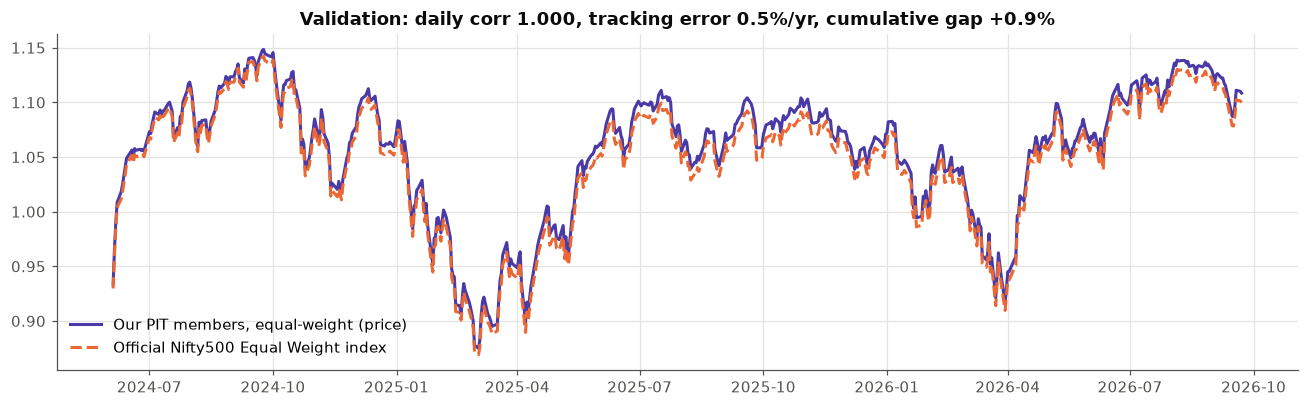

In [10]:
IDX = pd.read_parquet(f"{D}/nse_indices.parquet").reindex(CAL).ffill()
ew_px = pd.Series(np.nan, index=CAL)
for d in CAL[CAL >= "2024-06-01"]:
    m = [s for s in members(d) if s in RETPX.columns]
    ew_px[d] = RETPX.loc[d, m].mean()
off = IDX["close|NIFTY500 EQUAL WEIGHT"].pct_change()
w = pd.concat([ew_px, off], axis=1, keys=["ours", "official"]).loc["2024-06-04":].dropna()
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot((1 + w.ours).cumprod(), color=COL["EW Nifty 500 (PIT)"], label="Our PIT members, equal-weight (price)")
ax.plot((1 + w.official).cumprod(), color=COL["Nifty 50 TR"], ls="--", label="Official Nifty500 Equal Weight index")
ax.legend(); ax.set_title(f"Validation: daily corr {w.corr().iloc[0,1]:.3f}, tracking error "
                          f"{(w.ours - w.official).std() * np.sqrt(252):.1%}/yr, "
                          f"cumulative gap {(1+w.ours).prod() - (1+w.official).prod():+.1%}")
plt.tight_layout(); save(fig, "02_ew_validation"); plt.show()

## 5. Benchmarks

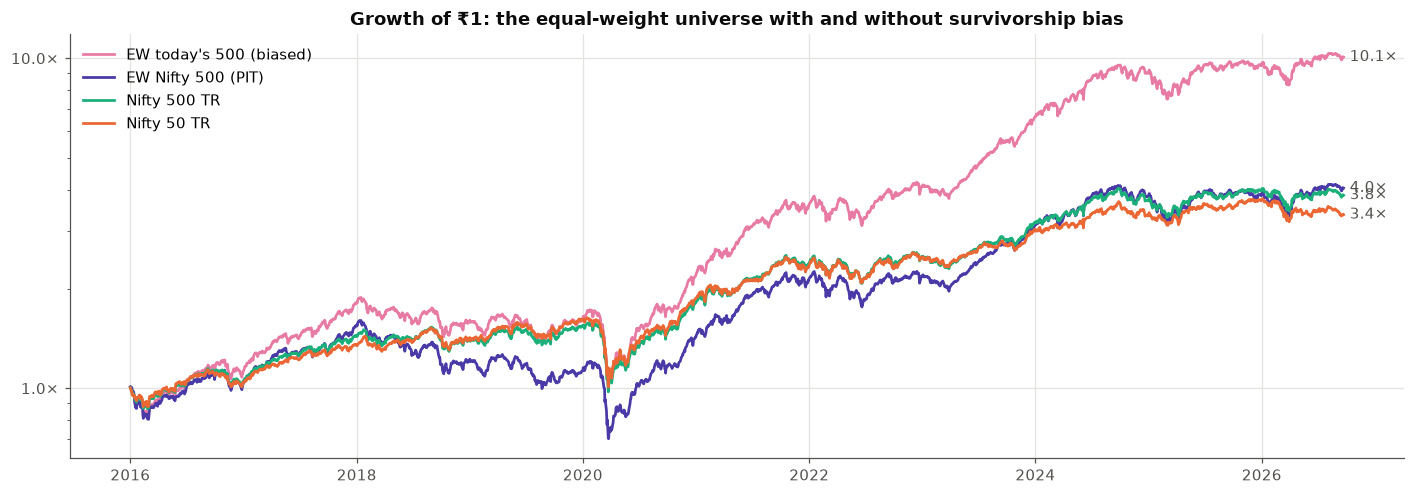

CAGR since 2016: Nifty 50: 10.8%  |  Nifty 50 TR: 12.2%  |  Nifty 500 TR: 13.6%  |  EW Nifty 500 (PIT): 14.2%  |  EW today's 500 (biased): 24.5%
Survivorship bias in an equal-weight Nifty 500 portfolio: +10.3% CAGR


In [11]:
def tri_from(price, dy):   # daily dividend accrual from NSE's published index dividend yield
    return (price.pct_change() + dy.shift() / 100 / 252).fillna(0)
start = pd.Timestamp(CONFIG["START"])
bench = pd.DataFrame({
    "Nifty 50":     IDX["close|NIFTY 50"].pct_change().fillna(0),
    "Nifty 50 TR":  tri_from(IDX["close|NIFTY 50"], IDX["dy|NIFTY 50"]),
    "Nifty 500 TR": tri_from(IDX["close|NIFTY 500"], IDX["dy|NIFTY 500"]),
}).loc[start:]
ew = pd.Series(np.nan, index=CAL)
for d in CAL[CAL >= start]:
    m = [s for s in members(d - pd.Timedelta(days=1)) if s in RET.columns]
    ew[d] = RET.loc[d, m].mean()
bench["EW Nifty 500 (PIT)"] = ew.loc[start:].fillna(0)
ew_b = RET.loc[start:, [s for s in current if s in RET.columns]].mean(axis=1)
bench["EW today's 500 (biased)"] = ew_b.fillna(0)
cumb = (1 + bench).cumprod()
fig, ax = plt.subplots(figsize=(13, 4.6))
for k, c in [("EW today's 500 (biased)", COL["Survivor-biased"]), ("EW Nifty 500 (PIT)", COL["EW Nifty 500 (PIT)"]),
             ("Nifty 500 TR", COL["Nifty 500 TR"]), ("Nifty 50 TR", COL["Nifty 50 TR"])]:
    ax.plot(cumb.index, cumb[k], color=c, lw=1.8, label=k)
    ax.annotate(f"{cumb[k].iloc[-1]:.1f}×", (cumb.index[-1], cumb[k].iloc[-1]), xytext=(4, 0), textcoords="offset points", color=INK2, va="center")
ax.set_yscale("log"); ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f×")); ax.legend(loc="upper left")
ax.set_title("Growth of ₹1: the equal-weight universe with and without survivorship bias")
plt.tight_layout(); save(fig, "03_benchmarks"); plt.show()
n = len(bench) / 252
cg = (cumb.iloc[-1] ** (1 / n) - 1)
print("CAGR since 2016:", "  |  ".join(f"{k}: {v:.1%}" for k, v in cg.items()))
print(f"Survivorship bias in an equal-weight Nifty 500 portfolio: {cg['EW today\'s 500 (biased)'] - cg['EW Nifty 500 (PIT)']:+.1%} CAGR")

## 6. Exploratory analysis on the point-in-time universe

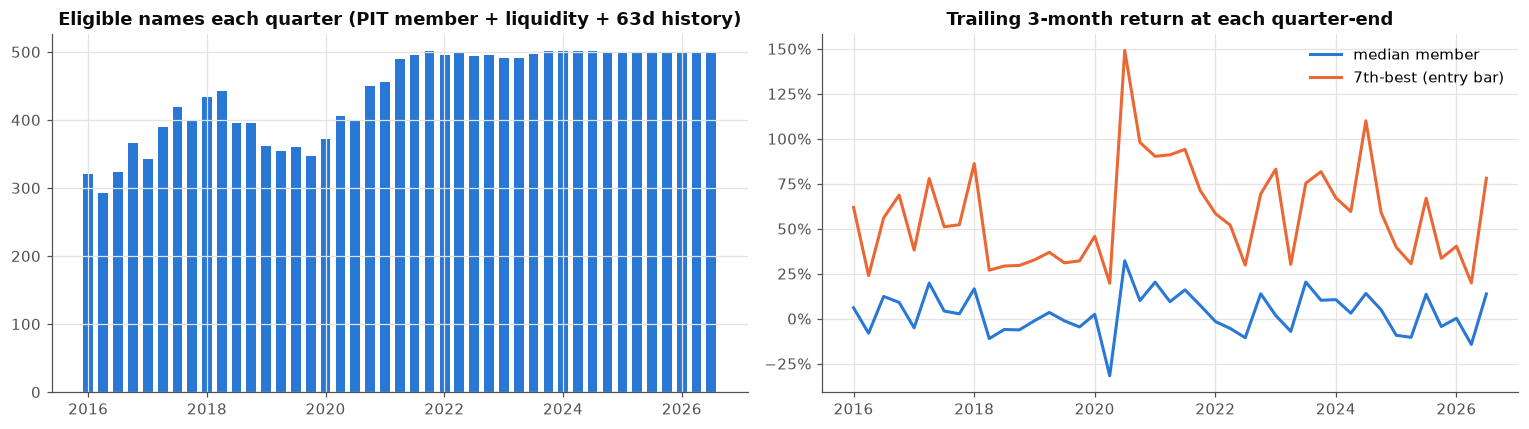

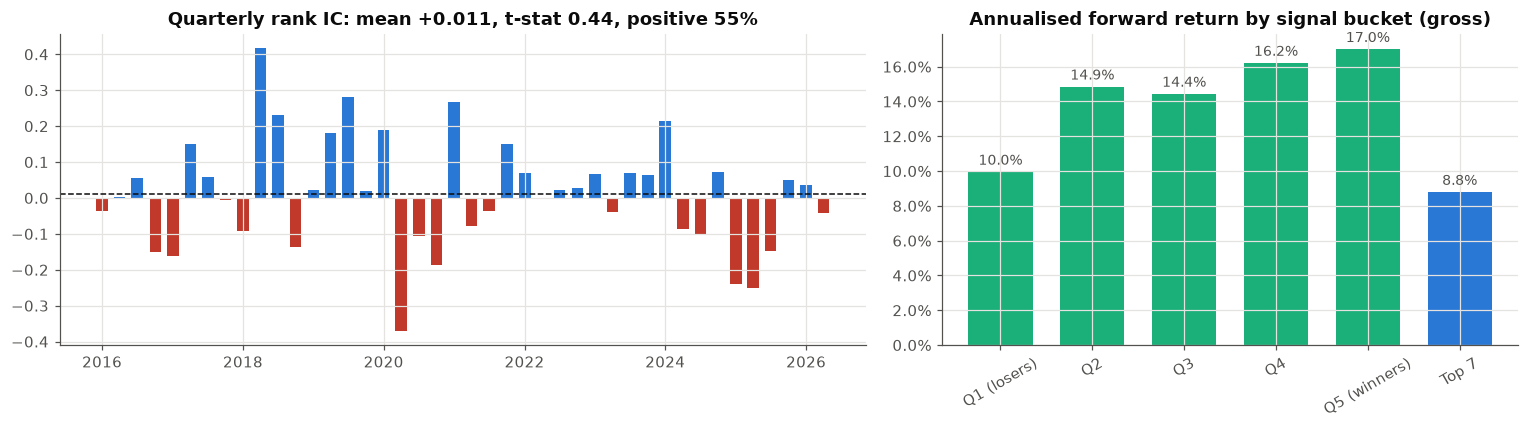

Mean rank IC +0.011 (t = 0.44); annualised gross return by bucket: Q1 (losers) 10.0%, Q2 14.9%, Q3 14.4%, Q4 16.2%, Q5 (winners) 17.0%, Top 7 8.8%


In [12]:
def rebalance_dates(start, months):
    d = pd.Series(CAL, index=CAL).loc[start:]
    first = d.groupby([d.index.year, d.index.month]).first()
    return [x for x in first.values if pd.Timestamp(x).month in months]
REB = [pd.Timestamp(x) for x in rebalance_dates(CONFIG["START"], CONFIG["REBAL_MONTHS"])]
POS = {d: CAL.get_loc(d) for d in CAL}
TRIf = TRI.ffill(limit=5)

UNIVERSES = {"pit": members, "today": lambda d: current}
def eligible(sig_day, lookback, skip, min_tv, universe="pit"):
    i = POS[sig_day]
    U = sorted(s for s in UNIVERSES[universe](sig_day) if s in TRI.columns)
    mom = TRIf.iloc[i - skip][U] / TRIf.iloc[i - skip - lookback][U] - 1
    liq = TV.iloc[i - lookback + 1:i + 1][U].median()
    return mom[mom.notna() & (liq >= min_tv) & TRIf.iloc[i][U].notna()]

L, S = CONFIG["LOOKBACK_DAYS"], CONFIG["SKIP_DAYS"]
SIG = {d: CAL[POS[d] - 1] for d in REB}
fwd_rows = []
for k, d in enumerate(REB):
    end = REB[k + 1] if k + 1 < len(REB) else CAL[-1]
    fwd_rows.append((TRI.ffill().loc[end] / TRI.loc[d] - 1).rename(d))
FWD = pd.DataFrame(fwd_rows)
qstats = pd.DataFrame({d: eligible(SIG[d], L, S, CONFIG["MIN_MEDIAN_TV_CR"]).describe(percentiles=[.5]) for d in REB}).T
top_cut = pd.Series({d: eligible(SIG[d], L, S, CONFIG["MIN_MEDIAN_TV_CR"]).nlargest(CONFIG["TOP_N"]).min() for d in REB})
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(qstats.index, qstats["count"], width=60, color=COL["Momentum Top 7"])
ax[0].set_title("Eligible names each quarter (PIT member + liquidity + 63d history)")
ax[1].plot(qstats.index, qstats["50%"], color=COL["Momentum Top 7"], label="median member")
ax[1].plot(top_cut.index, top_cut, color=COL["Nifty 50 TR"], label="7th-best (entry bar)")
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax[1].legend(); ax[1].set_title("Trailing 3-month return at each quarter-end")
plt.tight_layout(); save(fig, "04_universe_eda"); plt.show()

ic, quint = [], []
for d in REB[:-1]:
    m = eligible(SIG[d], L, S, CONFIG["MIN_MEDIAN_TV_CR"]); f = FWD.loc[d].reindex(m.index).dropna(); m = m.loc[f.index]
    ic.append((d, m.rank().corr(f.rank())))
    q = pd.qcut(m.rank(method="first"), 5, labels=["Q1 (losers)", "Q2", "Q3", "Q4", "Q5 (winners)"])
    row = f.groupby(q).mean(); row["Top 7"] = f.loc[m.nlargest(CONFIG["TOP_N"]).index].mean(); quint.append(row.rename(d))
IC = pd.Series(dict(ic)); Q = pd.DataFrame(quint)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1.4, 1]})
ax[0].bar(IC.index, IC, width=60, color=np.where(IC > 0, COL["Momentum Top 7"], "#c0392b")); ax[0].axhline(IC.mean(), color=INK, ls="--", lw=1)
ax[0].set_title(f"Quarterly rank IC: mean {IC.mean():+.3f}, t-stat {IC.mean()/IC.std()*np.sqrt(len(IC)):.2f}, positive {(IC>0).mean():.0%}")
qa = (1 + Q).prod() ** (4 / len(Q)) - 1
ax[1].bar(qa.index, qa.values, color=[COL["Nifty 500 TR"]] * 5 + [COL["Momentum Top 7"]], width=0.7)
for i, v in enumerate(qa.values): ax[1].text(i, v + 0.004, f"{v:.1%}", ha="center", color=INK2, fontsize=9)
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax[1].tick_params(axis="x", rotation=30)
ax[1].set_title("Annualised forward return by signal bucket (gross)")
plt.tight_layout(); save(fig, "05_signal_quality"); plt.show()
print(f"Mean rank IC {IC.mean():+.3f} (t = {IC.mean()/IC.std()*np.sqrt(len(IC)):.2f}); annualised gross return by bucket: "
      + ", ".join(f"{k} {v:.1%}" for k, v in qa.items()))

## 7. Backtest engine
The engine is the same as in the first version, with one change: eligibility comes from **point-in-time membership**. `universe="today"` reproduces the survivor-biased
setup on the same prices, so the two runs differ **only** in their universe.

In [13]:
UNIVERSES = {"pit": members, "today": lambda d: current,
             "pit_and_today": lambda d: members(d) & current,   # PIT, but drop names that later left the index
             "pit_or_today": lambda d: members(d) | current}    # PIT, plus today's names before they joined
def eligible(sig_day, lookback, skip, min_tv, universe="pit"):
    i = POS[sig_day]
    U = sorted(s for s in UNIVERSES[universe](sig_day) if s in TRI.columns)
    mom = TRIf.iloc[i - skip][U] / TRIf.iloc[i - skip - lookback][U] - 1
    liq = TV.iloc[i - lookback + 1:i + 1][U].median()
    return mom[mom.notna() & (liq >= min_tv) & TRIf.iloc[i][U].notna()]

def backtest(lookback=L, top_n=CONFIG["TOP_N"], skip=S, cost=CONFIG["COST_PER_SIDE"], min_tv=CONFIG["MIN_MEDIAN_TV_CR"],
             months=CONFIG["REBAL_MONTHS"], start=CONFIG["START"], universe="pit"):
    reb = [pd.Timestamp(x) for x in rebalance_dates(start, months)]
    px = TRI.ffill()
    nav = pd.Series(np.nan, index=CAL[CAL >= reb[0]])
    equity, w_prev, log = 1.0, pd.Series(dtype=float), []
    for k, d in enumerate(reb):
        m = eligible(CAL[POS[d] - 1], lookback, skip, min_tv, universe)
        m = m[TRI.loc[d, m.index].notna()]
        picks = m.nlargest(top_n).index
        w_new = pd.Series(1.0 / len(picks), index=picks)
        allk = w_prev.index.union(w_new.index)
        trade = (w_new.reindex(allk, fill_value=0) - w_prev.reindex(allk, fill_value=0)).abs().sum()
        equity *= 1 - cost * trade
        end = reb[k + 1] if k + 1 < len(reb) else CAL[-1]
        seg = px.loc[d:end, picks]; val = (seg / seg.iloc[0]).mul(w_new, axis=1); path = equity * val.sum(axis=1)
        nav.loc[d:end] = path
        log.append(dict(rebal=d, picks=list(picks), signal=m.loc[picks].tolist(), fwd=(seg.iloc[-1] / seg.iloc[0] - 1).tolist(),
                        stopped=[p for p in picks if LAST_TRADE[p] < end], q_ret=path.iloc[-1] / equity - 1, turnover=trade / 2))
        equity, w_prev = path.iloc[-1], val.iloc[-1] / val.iloc[-1].sum()
    return nav.ffill(), pd.DataFrame(log)

nav, LOG = backtest()
nav_gross, _ = backtest(cost=0)
nav_bias, LOG_bias = backtest(universe="today")
R = pd.concat([nav.pct_change().rename("Momentum Top 7"), bench], axis=1).loc[nav.index].fillna(0)
R["Momentum (gross)"] = nav_gross.pct_change().reindex(R.index).fillna(0)
R["Momentum, today's list (biased)"] = nav_bias.pct_change().reindex(R.index).fillna(0)
print(f"{len(LOG)} rebalances; avg one-way turnover {LOG.turnover.mean():.0%}/quarter; "
      f"picks that stopped trading while held: {sum(len(x) for x in LOG.stopped)} → {sorted({s for x in LOG.stopped for s in x})}")

43 rebalances; avg one-way turnover 95%/quarter; picks that stopped trading while held: 0 → []


## 8. Results

In [14]:
def metrics(r, b=None, rf=CONFIG["RF_ANNUAL"]):
    r = r.dropna(); n = len(r) / 252; eq = (1 + r).cumprod(); dd = eq / eq.cummax() - 1
    cagr = eq.iloc[-1] ** (1 / n) - 1; vol = r.std() * np.sqrt(252)
    under = dd < 0; runs = (under != under.shift()).cumsum()[under]
    mo = (1 + r).resample("ME").prod() - 1
    out = {"CAGR": cagr, "Total return": eq.iloc[-1] - 1, "Ann. volatility": vol,
           "Sharpe (rf 6.5%)": (r.mean() - rf / 252) / r.std() * np.sqrt(252),
           "Sortino": (r.mean() * 252 - rf) / (r[r < 0].std() * np.sqrt(252)), "Max drawdown": dd.min(),
           "Calmar": cagr / -dd.min(), "Longest DD (days)": runs.value_counts().max() if len(runs) else 0,
           "% positive months": (mo > 0).mean(), "Best month": mo.max(), "Worst month": mo.min()}
    if b is not None:
        b = b.loc[r.index]; beta = np.cov(r, b)[0, 1] / b.var(); act = r - b; bm = (1 + b).resample("ME").prod() - 1
        te = act.std() * np.sqrt(252)
        out.update({"Beta vs Nifty 50 TR": beta, "Alpha (ann.)": (r.mean() - rf / 252 - beta * (b.mean() - rf / 252)) * 252,
                    "Tracking error": te, "Information ratio": act.mean() * 252 / te if te > 0.01 else np.nan,
                    "Up capture": mo[bm > 0].mean() / bm[bm > 0].mean(), "Down capture": mo[bm < 0].mean() / bm[bm < 0].mean(),
                    "% months beating Nifty 50 TR": (mo > bm).mean()})
    return pd.Series(out)
cols = ["Momentum Top 7", "Momentum (gross)", "Nifty 50 TR", "Nifty 50", "Nifty 500 TR", "EW Nifty 500 (PIT)", "Momentum, today's list (biased)"]
M = pd.DataFrame({c: metrics(R[c], R["Nifty 50 TR"]) for c in cols})
PCT = ["CAGR", "Total return", "Ann. volatility", "Max drawdown", "% positive months", "Best month", "Worst month",
       "Alpha (ann.)", "Tracking error", "% months beating Nifty 50 TR"]
fmt = M.astype(object).copy()
for r_ in M.index:
    fmt.loc[r_] = [("{:.1%}" if r_ in PCT else "{:.0f}" if "days" in r_ else "{:.2f}").format(v) if v == v else "–" for v in M.loc[r_]]
display(fmt)

,Momentum Top 7,Momentum (gross),Nifty 50 TR,Nifty 50,Nifty 500 TR,EW Nifty 500 (PIT),"Momentum, today's list (biased)"
CAGR,7.8%,9.9%,12.2%,10.8%,13.6%,14.2%,31.0%
Total return,120.6%,169.9%,235.6%,193.6%,284.4%,304.2%,1620.5%
Ann. volatility,29.4%,29.4%,16.1%,16.1%,16.1%,17.8%,29.7%
Sharpe (rf 6.5%),0.18,0.25,0.39,0.31,0.47,0.47,0.84
Sortino,0.25,0.34,0.48,0.38,0.56,0.54,1.14
Max drawdown,-54.9%,-53.3%,-38.3%,-38.4%,-38.2%,-56.2%,-47.6%
Calmar,0.14,0.19,0.32,0.28,0.36,0.25,0.65
Longest DD (days),668,659,264,314,492,770,549
% positive months,61.2%,61.2%,58.9%,56.6%,62.8%,61.2%,69.8%
Best month,22.3%,22.9%,14.8%,14.7%,14.7%,16.9%,28.4%


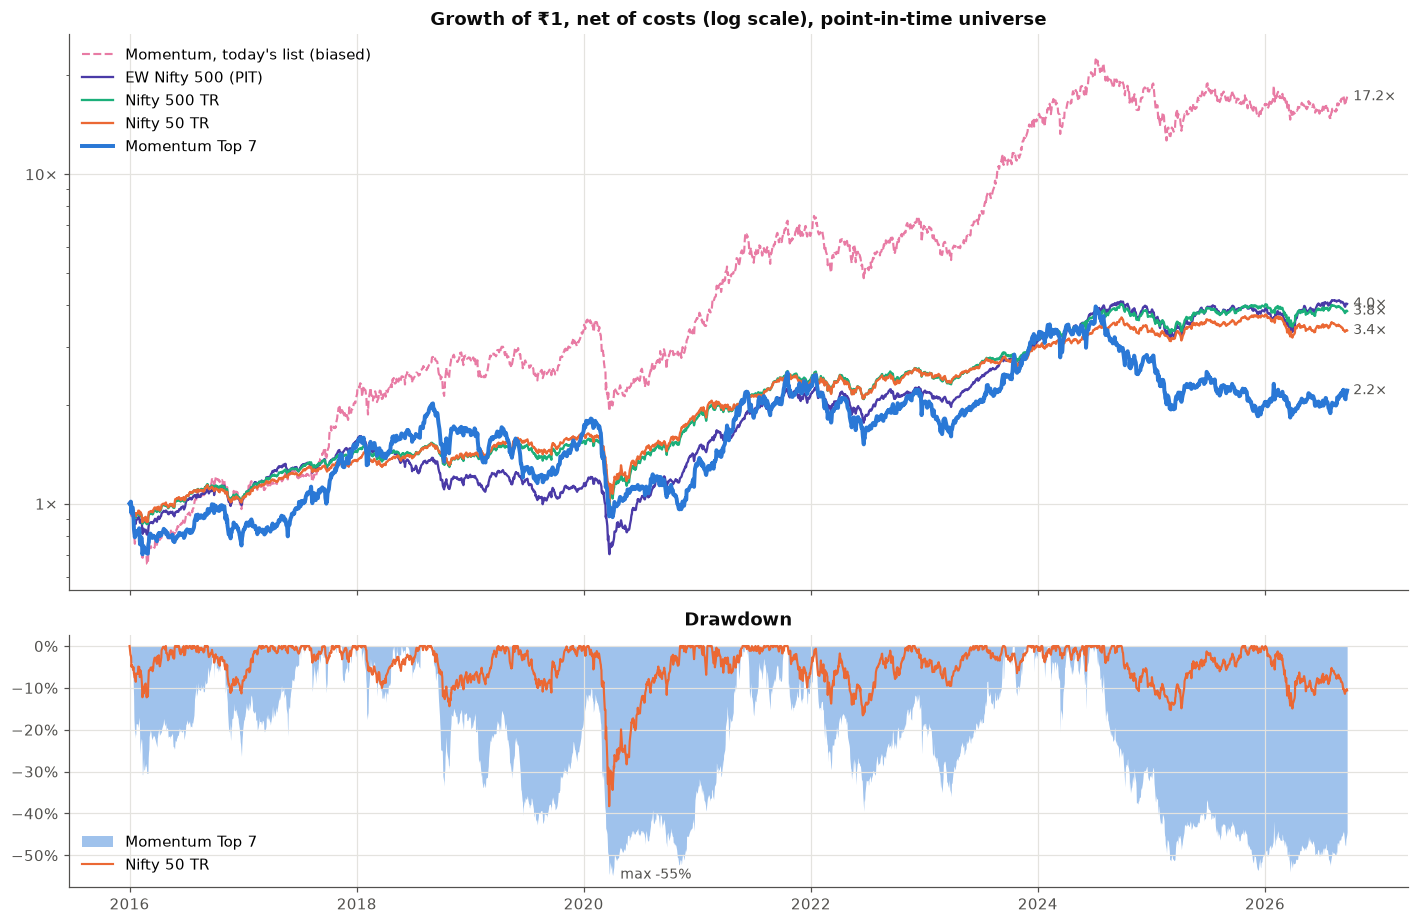

In [15]:
cum = (1 + R).cumprod()
fig, ax = plt.subplots(2, 1, figsize=(13, 8.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
for c, colr, lw, ls in [("Momentum, today's list (biased)", COL["Survivor-biased"], 1.4, "--"),
                        ("EW Nifty 500 (PIT)", COL["EW Nifty 500 (PIT)"], 1.5, "-"), ("Nifty 500 TR", COL["Nifty 500 TR"], 1.5, "-"),
                        ("Nifty 50 TR", COL["Nifty 50 TR"], 1.5, "-"), ("Momentum Top 7", COL["Momentum Top 7"], 2.6, "-")]:
    ax[0].plot(cum.index, cum[c], color=colr, lw=lw, ls=ls, label=c)
    ax[0].annotate(f"{cum[c].iloc[-1]:.1f}×", (cum.index[-1], cum[c].iloc[-1]), xytext=(4, 0), textcoords="offset points", color=INK2, va="center", fontsize=9)
ax[0].set_yscale("log"); ax[0].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f×")); ax[0].legend(loc="upper left")
ax[0].set_title("Growth of ₹1, net of costs (log scale), point-in-time universe")
dd = cum["Momentum Top 7"] / cum["Momentum Top 7"].cummax() - 1; dn = cum["Nifty 50 TR"] / cum["Nifty 50 TR"].cummax() - 1
ax[1].fill_between(dd.index, dd, 0, color=COL["Momentum Top 7"], alpha=0.45, lw=0, label="Momentum Top 7")
ax[1].plot(dn.index, dn, color=COL["Nifty 50 TR"], lw=1.4, label="Nifty 50 TR")
ax[1].annotate(f"max {dd.min():.0%}", (dd.idxmin(), dd.min()), xytext=(5, -2), textcoords="offset points", color=INK2, fontsize=9)
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax[1].set_title("Drawdown"); ax[1].legend(loc="lower left")
plt.tight_layout(); save(fig, "06_equity_drawdown"); plt.show()

### 8.1 How much of the first version's result was survivorship bias?

,Survivor-biased (today's list),Point-in-time (true),Bias
CAGR,+31.0%,+7.8%,+23.2%
Sharpe,0.84,0.18,0.66
Max drawdown,-47.6%,-54.9%,+7.2%


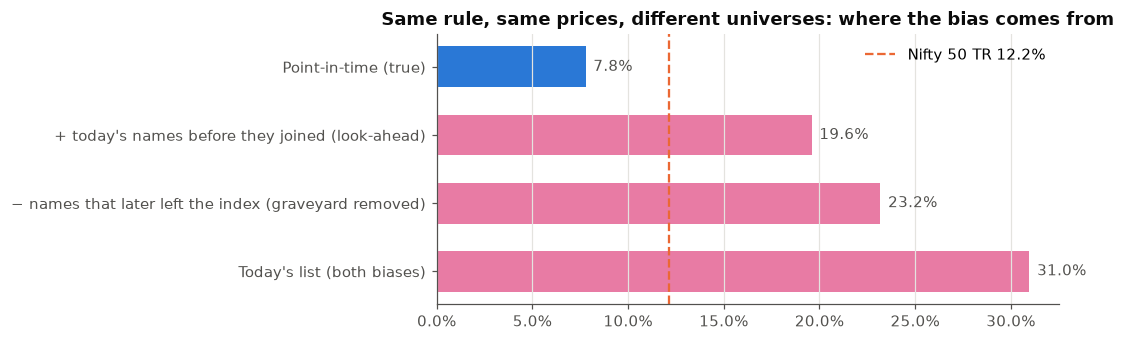

,CAGR,Sharpe (rf 6.5%),Max drawdown
Point-in-time (true),7.8%,0.18,-54.9%
+ today's names before they joined (look-ahead),19.6%,0.53,-54.7%
− names that later left the index (graveyard removed),23.2%,0.65,-53.0%
Today's list (both biases),31.0%,0.84,-47.6%


**Point-in-time picks split by whether the stock is still in today's Nifty 500.** A survivor-biased backtest can only ever pick the `True` row:

,picks,mean_next_q,median_next_q,hit_rate
in today's list,,,,
False,86,-1.7%,-4.7%,42%
True,215,+6.0%,+2.6%,54%


In [16]:
sb = pd.DataFrame({
    "Survivor-biased (today's list)": [M.loc["CAGR", "Momentum, today's list (biased)"], M.loc["Sharpe (rf 6.5%)", "Momentum, today's list (biased)"], M.loc["Max drawdown", "Momentum, today's list (biased)"]],
    "Point-in-time (true)":            [M.loc["CAGR", "Momentum Top 7"], M.loc["Sharpe (rf 6.5%)", "Momentum Top 7"], M.loc["Max drawdown", "Momentum Top 7"]],
}, index=["CAGR", "Sharpe", "Max drawdown"])
sb["Bias"] = sb.iloc[:, 0] - sb.iloc[:, 1]
display(sb.style.format("{:.2f}", subset=pd.IndexSlice[["Sharpe"], :]).format("{:+.1%}", subset=pd.IndexSlice[["CAGR", "Max drawdown"], :]))
dec = {}
for u, lbl in [("pit", "Point-in-time (true)"), ("pit_or_today", "+ today's names before they joined (look-ahead)"),
               ("pit_and_today", "− names that later left the index (graveyard removed)"), ("today", "Today's list (both biases)")]:
    nv_ = backtest(universe=u)[0]; dec[lbl] = metrics(nv_.pct_change().fillna(0))[["CAGR", "Sharpe (rf 6.5%)", "Max drawdown"]]
DEC = pd.DataFrame(dec).T
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.barh(DEC.index[::-1], DEC.CAGR[::-1], color=[COL["Survivor-biased"]] * 3 + [COL["Momentum Top 7"]], height=0.6)
for i, v in enumerate(DEC.CAGR[::-1]): ax.text(v + 0.004, i, f"{v:.1%}", va="center", color=INK2)
ax.axvline(M.loc["CAGR", "Nifty 50 TR"], color=COL["Nifty 50 TR"], ls="--", lw=1.5, label=f"Nifty 50 TR {M.loc['CAGR','Nifty 50 TR']:.1%}")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.legend(loc="upper right"); ax.grid(axis="y", visible=False)
ax.set_title("Same rule, same prices, different universes: where the bias comes from")
plt.tight_layout(); save(fig, "06b_bias_decomposition"); plt.show()
display(DEC.style.format({"CAGR": "{:.1%}", "Sharpe (rf 6.5%)": "{:.2f}", "Max drawdown": "{:.1%}"}))
H = pd.DataFrame([dict(rebal=r.rebal, ticker=t, trailing_3m=s, next_q=f) for _, r in LOG.iterrows()
                  for t, s, f in zip(r.picks, r.signal, r.fwd)])
H["in today's list"] = H.ticker.isin(current)
g = H.groupby("in today's list").agg(picks=("next_q", "size"), mean_next_q=("next_q", "mean"), median_next_q=("next_q", "median"), hit_rate=("next_q", lambda x: (x > 0).mean()))
display(Markdown("**Point-in-time picks split by whether the stock is still in today's Nifty 500.** "
                 "A survivor-biased backtest can only ever pick the `True` row:"))
display(g.style.format({"mean_next_q": "{:+.1%}", "median_next_q": "{:+.1%}", "hit_rate": "{:.0%}"}))

### 8.2 Calendar-year returns

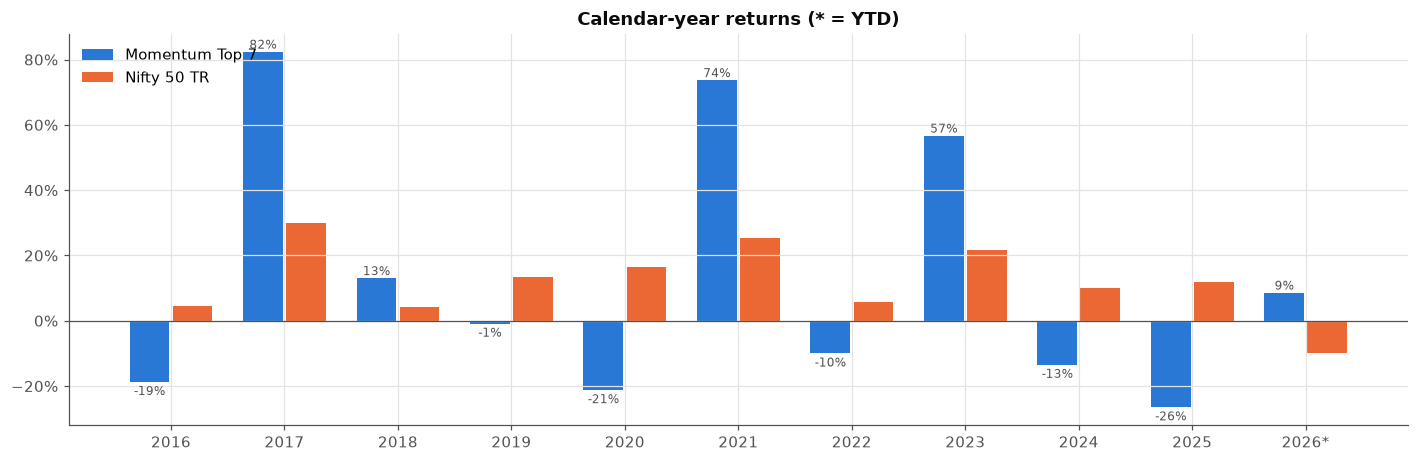

,Momentum Top 7,Nifty 50 TR,Nifty 500 TR,EW Nifty 500 (PIT),Excess vs Nifty 50 TR
2016,-18.8%,4.4%,5.2%,3.1%,-23.2%
2017,82.3%,30.1%,37.3%,50.3%,52.2%
2018,13.0%,4.4%,-2.4%,-21.2%,8.6%
2019,-0.9%,13.4%,8.9%,-7.3%,-14.3%
2020,-21.2%,16.6%,18.3%,26.5%,-37.8%
2021,73.6%,25.5%,31.6%,49.9%,48.1%
2022,-10.0%,5.7%,4.3%,2.0%,-15.7%
2023,56.6%,21.7%,27.4%,42.0%,35.0%
2024,-13.5%,10.1%,16.4%,23.2%,-23.6%
2025,-26.5%,11.9%,7.9%,1.3%,-38.4%


In [17]:
yr = (1 + R[["Momentum Top 7", "Nifty 50 TR", "Nifty 500 TR", "EW Nifty 500 (PIT)"]]).resample("YE").prod() - 1; yr.index = yr.index.year
yr["Excess vs Nifty 50 TR"] = yr["Momentum Top 7"] - yr["Nifty 50 TR"]
fig, ax = plt.subplots(figsize=(13, 4.3)); x = np.arange(len(yr)); w_ = 0.38
ax.bar(x - w_/2, yr["Momentum Top 7"], w_ - 0.03, color=COL["Momentum Top 7"], label="Momentum Top 7")
ax.bar(x + w_/2, yr["Nifty 50 TR"], w_ - 0.03, color=COL["Nifty 50 TR"], label="Nifty 50 TR")
for i, v in enumerate(yr["Momentum Top 7"]): ax.text(i - w_/2, v + (0.01 if v >= 0 else -0.04), f"{v:.0%}", ha="center", fontsize=8, color=INK2)
ax.set_xticks(x, [f"{y}{'*' if y == yr.index[-1] else ''}" for y in yr.index]); ax.axhline(0, color=INK2, lw=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.legend(loc="upper left"); ax.set_title("Calendar-year returns (* = YTD)")
plt.tight_layout(); save(fig, "07_yearly"); plt.show()
display(yr.style.format("{:.1%}").background_gradient(cmap=DIV, subset=["Excess vs Nifty 50 TR"], vmin=-0.5, vmax=0.5))

### 8.3 Monthly heatmap and rolling behaviour

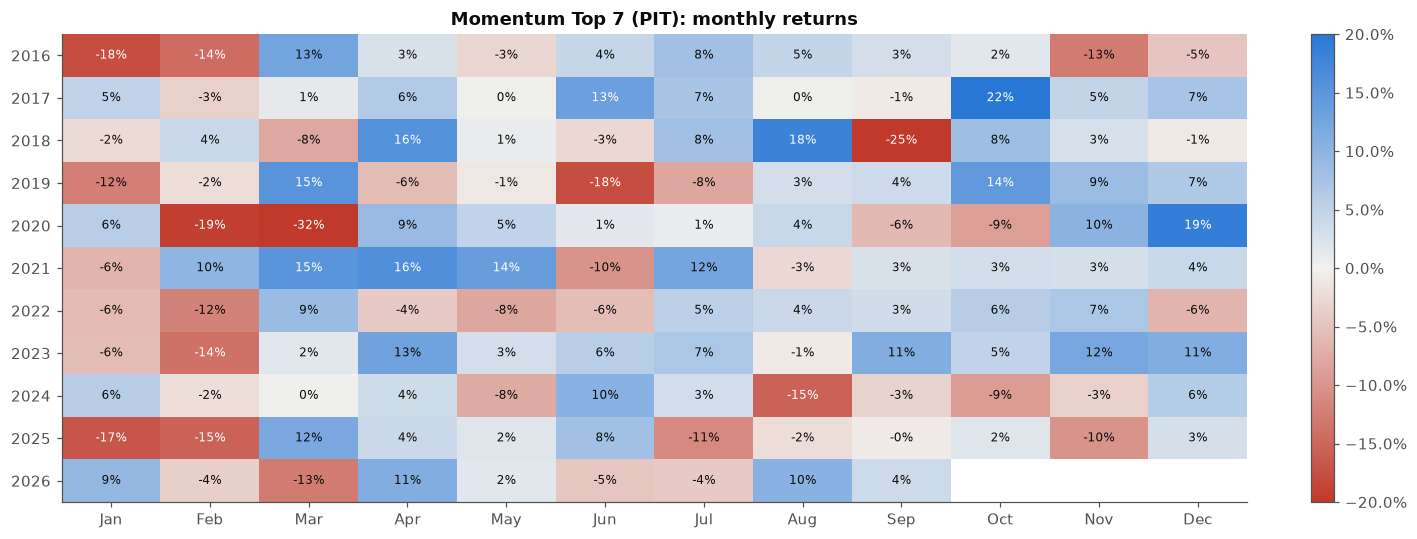

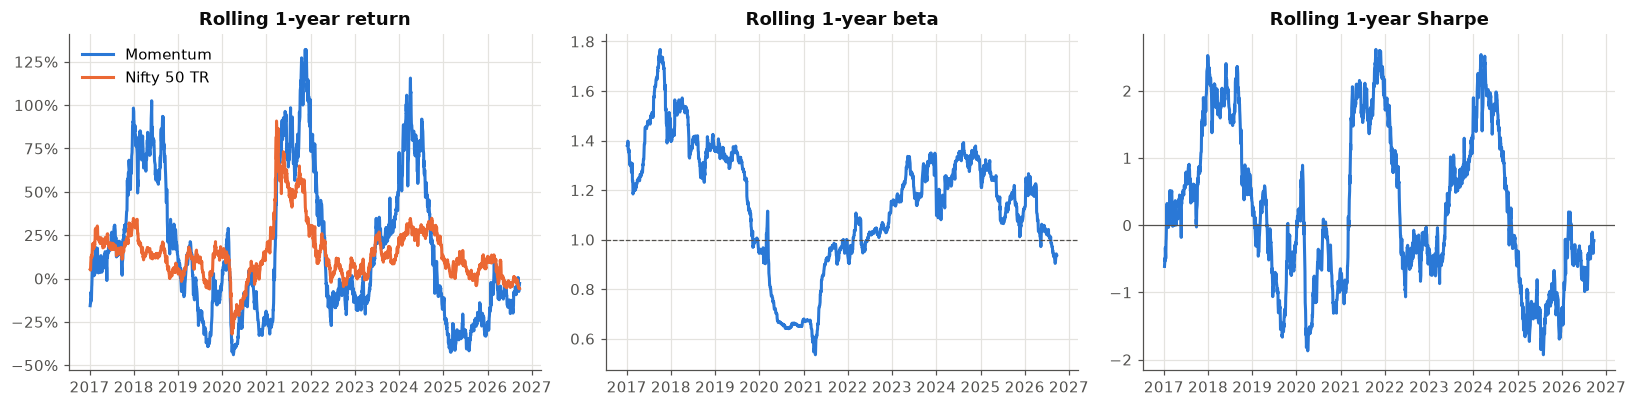

Rolling 1y windows where Momentum beat Nifty 50 TR: 40%


In [18]:
mo = (1 + R["Momentum Top 7"]).resample("ME").prod() - 1
hm = mo.to_frame("r").assign(Y=mo.index.year, M=mo.index.strftime("%b")).pivot(index="Y", columns="M", values="r")
hm = hm[["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]]
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(hm.values, cmap=DIV, vmin=-0.2, vmax=0.2, aspect="auto")
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        v = hm.values[i, j]
        if v == v: ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8, color="white" if abs(v) > 0.13 else INK)
ax.set_xticks(range(12), hm.columns); ax.set_yticks(range(len(hm)), hm.index); ax.grid(False)
ax.set_title("Momentum Top 7 (PIT): monthly returns"); plt.colorbar(im, ax=ax, format=mtick.PercentFormatter(1), fraction=0.02)
plt.tight_layout(); save(fig, "08_monthly_heatmap"); plt.show()

W = 252
r1 = (1 + R["Momentum Top 7"]).rolling(W).apply(np.prod, raw=True) - 1; b1 = (1 + R["Nifty 50 TR"]).rolling(W).apply(np.prod, raw=True) - 1
rb = R["Momentum Top 7"].rolling(W).cov(R["Nifty 50 TR"]) / R["Nifty 50 TR"].rolling(W).var()
rs = (R["Momentum Top 7"] - CONFIG["RF_ANNUAL"]/252).rolling(W).mean() / R["Momentum Top 7"].rolling(W).std() * np.sqrt(252)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].plot(r1, color=COL["Momentum Top 7"], label="Momentum"); ax[0].plot(b1, color=COL["Nifty 50 TR"], label="Nifty 50 TR")
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax[0].legend(); ax[0].set_title("Rolling 1-year return")
ax[1].plot(rb, color=COL["Momentum Top 7"]); ax[1].axhline(1, color=INK2, lw=0.8, ls="--"); ax[1].set_title("Rolling 1-year beta")
ax[2].plot(rs, color=COL["Momentum Top 7"]); ax[2].axhline(0, color=INK2, lw=0.8); ax[2].set_title("Rolling 1-year Sharpe")
plt.tight_layout(); save(fig, "09_rolling"); plt.show()
print(f"Rolling 1y windows where Momentum beat Nifty 50 TR: {(r1 > b1)[r1.notna()].mean():.0%}")

## 9. Holdings

In [19]:
SECTOR = {}
for f in sorted(glob.glob(f"{D}/n500_snapshots/*.csv")) + [f"{D}/ind_nifty500list.csv"]:
    s_ = pd.read_csv(f); SECTOR.update(dict(zip(s_.Symbol.str.strip().map(canon), s_.Industry.str.strip().str.title())))
H["sector"] = H.ticker.map(SECTOR).fillna("Unknown")
nq = (1 + R["Nifty 50 TR"]).cumprod()
qt = LOG.assign(Quarter=LOG.rebal.dt.to_period("Q").astype(str),
                Holdings=LOG.picks.apply(lambda p: ", ".join(x if x in current else x + "†" for x in p)))
qt["Nifty 50 TR"] = [nq.asof(REB[k + 1] if k + 1 < len(REB) else nq.index[-1]) / nq.asof(d) - 1 for k, d in enumerate(LOG.rebal)]
display(Markdown("† = no longer in today's Nifty 500"))
display(qt[["Quarter", "Holdings", "q_ret", "Nifty 50 TR", "turnover"]].rename(columns={"q_ret": "Strategy (net)", "turnover": "Turnover"})
        .style.format({"Strategy (net)": "{:+.1%}", "Nifty 50 TR": "{:+.1%}", "Turnover": "{:.0%}"})
        .background_gradient(cmap=DIV, subset=["Strategy (net)"], vmin=-0.4, vmax=0.4).hide(axis="index"))

† = no longer in today's Nifty 500

Quarter,Holdings,Strategy (net),Nifty 50 TR,Turnover
2016Q1,"GODFRYPHLP, HCL-INSYS†, LITL†, FCONSUMER†, RENUKA†, JINDALSTEL, FSL",-19.4%,-2.8%,50%
2016Q2,"BALRAMCHIN, TORNTPOWER, GPPL†, HINDZINC, NHPC, TATASTEEL, JSWSTEEL",+3.3%,+8.3%,100%
2016Q3,"MANAPPURAM, EMBDL†, MUTHOOTFIN, VGUARD†, ACLGATI†, ESCORTS, MONSANTO†",+20.1%,+5.2%,100%
2016Q4,"JUBLPHARMA, DISHMAN†, IDFCFIRSTB, DELTACORP†, HCC†, ESCORTS, JKTYRE",-15.0%,-6.1%,86%
2017Q1,"SWANCORP, ADANIENSOL, MOIL†, PGHL†, NATIONALUM, BALMLAWRIE†, HCL-INSYS†",+2.2%,+13.3%,100%
2017Q2,"KOLTEPATIL†, FRETAIL†, RAIN†, JPASSOCIAT†, ESCORTS, SUNTECK†, DREDGECORP†",+18.3%,+4.4%,100%
2017Q3,"EMBDL†, AVANTIFEED†, ADANIENSOL, MOTILALOFS, JPASSOCIAT†, CANFINHOME, POONAWALLA",+11.5%,+2.8%,86%
2017Q4,"BOMDYEING†, HFCL, FCONSUMER†, DHANI†, JSL, STLTECH†, RAIN†",+37.3%,+6.1%,100%
2018Q1,"SECURKLOUD†, RAIN†, KOLTEPATIL†, RELIGARE†, SONATSOFTW, IFBIND†, RADICO",-5.7%,-1.9%,86%
2018Q2,"COFORGE, GVPIL†, FSL, JUBLFOOD, TECHM, MINDTREE†, LTTS",+10.9%,+4.7%,100%


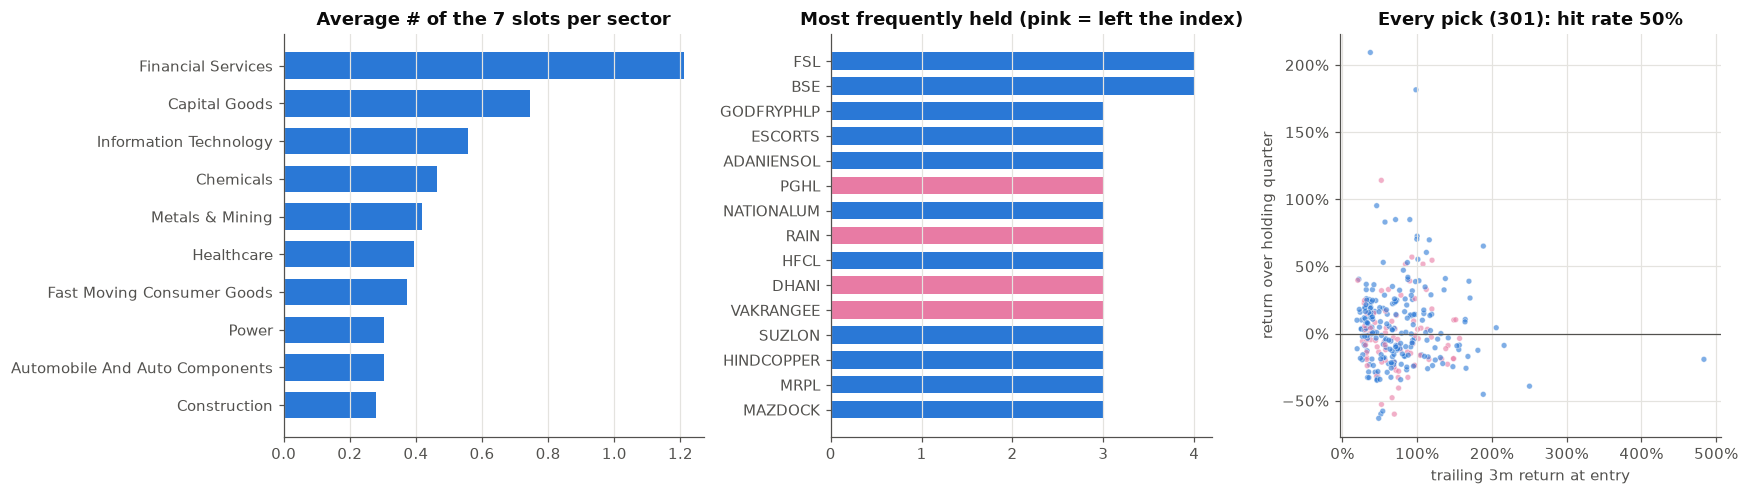

Median pick return per quarter +0.1%, mean +3.8%


side,rebal,ticker,sector,in today's list,trailing_3m,next_q
Best,2019-10,ADANIGREEN,Power,True,+38%,+209%
Best,2021-01,ATGL,Oil Gas & Consumable Fuels,True,+99%,+181%
Best,2017-10,RAIN,Chemicals,False,+52%,+114%
Best,2018-10,ADANIPOWER,Power,True,+46%,+95%
Best,2026-07,WELCORP,Capital Goods,True,+90%,+85%
Best,2021-10,TRIDENT,Textiles,True,+71%,+85%
Best,2016-07,ESCORTS,Capital Goods,True,+57%,+83%
Best,2021-07,FLUOROCHEM,Chemicals,True,+100%,+73%
Worst,2020-01,TMPV,Automobile And Auto Components,True,+49%,-63%
Worst,2020-01,VAKRANGEE,Information Technology,False,+70%,-60%


In [20]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.1, 1, 1]})
ss = H.sector.value_counts().head(10)[::-1]
ax[0].barh(ss.index, ss.values / len(LOG), color=COL["Momentum Top 7"], height=0.7); ax[0].set_title("Average # of the 7 slots per sector"); ax[0].grid(axis="y", visible=False)
fq = H.ticker.value_counts().head(15)[::-1]
ax[1].barh(fq.index, fq.values, color=[COL["Momentum Top 7"] if t in current else COL["Survivor-biased"] for t in fq.index], height=0.7)
ax[1].set_title("Most frequently held (pink = left the index)"); ax[1].grid(axis="y", visible=False)
ax[2].scatter(H.trailing_3m, H.next_q, s=14, c=np.where(H["in today's list"], COL["Momentum Top 7"], COL["Survivor-biased"]), alpha=0.6, edgecolor="white", lw=0.4)
ax[2].axhline(0, color=INK2, lw=0.8); ax[2].xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax[2].set_xlabel("trailing 3m return at entry"); ax[2].set_ylabel("return over holding quarter")
ax[2].set_title(f"Every pick ({len(H)}): hit rate {(H.next_q > 0).mean():.0%}")
plt.tight_layout(); save(fig, "10_holdings"); plt.show()
print(f"Median pick return per quarter {H.next_q.median():+.1%}, mean {H.next_q.mean():+.1%}")
bw = pd.concat([H.nlargest(8, "next_q").assign(side="Best"), H.nsmallest(8, "next_q").assign(side="Worst")])
display(bw[["side", "rebal", "ticker", "sector", "in today's list", "trailing_3m", "next_q"]]
        .style.format({"trailing_3m": "{:+.0%}", "next_q": "{:+.0%}", "rebal": lambda d: d.strftime("%Y-%m")}).hide(axis="index"))

## 10. Skill or luck? Random-7 Monte Carlo (point-in-time universe)

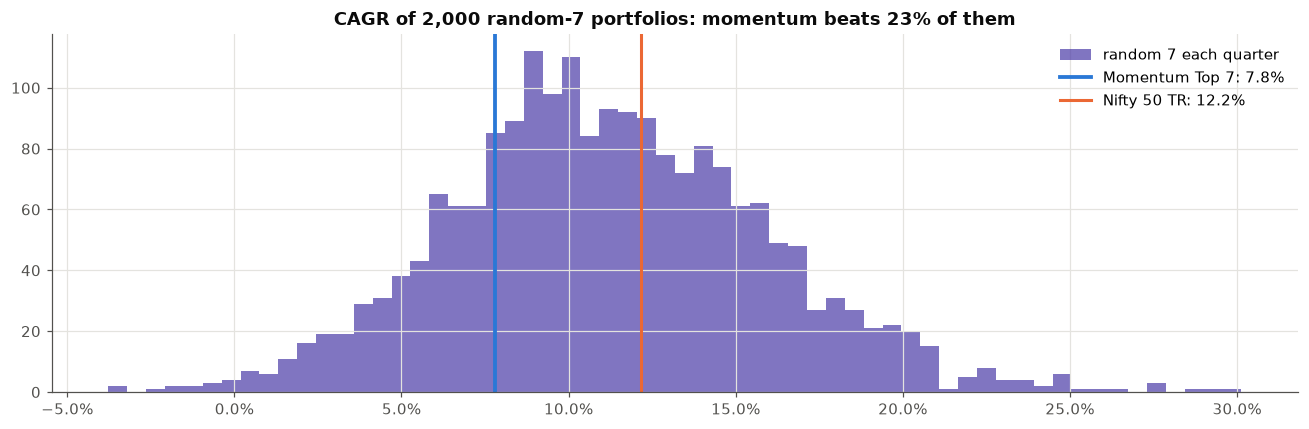

Momentum beats 23.0% of random portfolios | random median 10.9%, 5–95%: 3.7% – 19.3%


In [21]:
rng = np.random.default_rng(CONFIG["SEED"])
elig = {d: np.sort((lambda m: m[TRI.loc[d, m.index].notna()].index.to_numpy())(eligible(SIG[d], L, S, CONFIG["MIN_MEDIAN_TV_CR"]))) for d in REB}
FWDf = FWD.fillna(0)
n_years = (CAL[-1] - REB[0]).days / 365.25
sims = np.empty(CONFIG["N_RANDOM_SIMS"])
for s_ in range(len(sims)):
    eq = 1.0
    for d in REB:
        p = rng.choice(elig[d], CONFIG["TOP_N"], replace=False)
        eq *= (1 + FWDf.loc[d, p].mean()) * (1 - 2 * CONFIG["COST_PER_SIDE"])
    sims[s_] = eq ** (1 / n_years) - 1
sc_ = M.loc["CAGR", "Momentum Top 7"]; pctile = (sims < sc_).mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(sims, bins=60, color=COL["EW Nifty 500 (PIT)"], alpha=0.7, label="random 7 each quarter")
ax.axvline(sc_, color=COL["Momentum Top 7"], lw=2.5, label=f"Momentum Top 7: {sc_:.1%}")
ax.axvline(M.loc["CAGR", "Nifty 50 TR"], color=COL["Nifty 50 TR"], lw=2, label=f"Nifty 50 TR: {M.loc['CAGR','Nifty 50 TR']:.1%}")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1)); ax.legend()
ax.set_title(f"CAGR of {len(sims):,} random-7 portfolios: momentum beats {pctile:.0%} of them")
plt.tight_layout(); save(fig, "11_monte_carlo"); plt.show()
print(f"Momentum beats {pctile:.1%} of random portfolios | random median {np.median(sims):.1%}, 5–95%: {np.percentile(sims,5):.1%} – {np.percentile(sims,95):.1%}")

## 11. Robustness

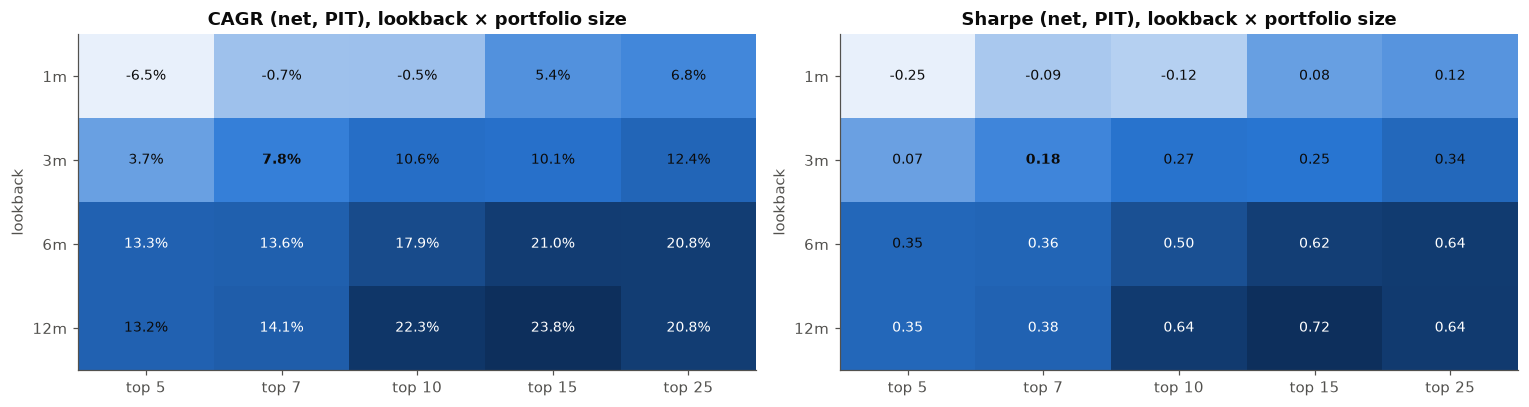

In [22]:
grid = {}
for lb, lbl in [(21, "1m"), (63, "3m"), (126, "6m"), (252, "12m")]:
    for n_ in [5, 7, 10, 15, 25]:
        nv, _ = backtest(lookback=lb, top_n=n_); mm = metrics(nv.pct_change().fillna(0))
        grid[(lbl, n_)] = (mm["CAGR"], mm["Sharpe (rf 6.5%)"], mm["Max drawdown"])
G_ = pd.DataFrame(grid, index=["CAGR", "Sharpe", "MaxDD"]).T
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8))
for a, key, fm in [(ax[0], "CAGR", "{:.1%}"), (ax[1], "Sharpe", "{:.2f}")]:
    t = G_[key].unstack().loc[["1m", "3m", "6m", "12m"]]
    a.imshow(t.values, cmap=SEQ, aspect="auto")
    for i in range(t.shape[0]):
        for j in range(t.shape[1]):
            v = t.values[i, j]
            a.text(j, i, fm.format(v), ha="center", va="center", fontsize=9, color="white" if v > np.nanpercentile(t.values, 55) else INK,
                   fontweight="bold" if (t.index[i], t.columns[j]) == ("3m", 7) else "normal")
    a.set_xticks(range(t.shape[1]), [f"top {c}" for c in t.columns]); a.set_yticks(range(4), t.index); a.set_ylabel("lookback"); a.grid(False)
    a.set_title(f"{key} (net, PIT), lookback × portfolio size")
plt.tight_layout(); save(fig, "12_param_grid"); plt.show()
display(G_.style.format({"CAGR": "{:.1%}", "Sharpe": "{:.2f}", "MaxDD": "{:.1%}"}))

,CAGR,Ann. volatility,Sharpe (rf 6.5%),Max drawdown,Information ratio
"Base (3m, top 7, Jan/Apr/Jul/Oct)",7.8%,29.4%,0.18,-54.9%,-0.04
Skip latest month,23.0%,28.8%,0.64,-56.0%,0.51
Rebalance Feb/May/Aug/Nov,22.5%,29.3%,0.62,-45.4%,0.46
Rebalance Mar/Jun/Sep/Dec,19.5%,29.5%,0.53,-51.4%,0.33
Costs 0.5% per side,5.7%,29.4%,0.12,-56.3%,-0.12
No liquidity filter,8.5%,29.3%,0.20,-54.0%,-0.01
Liquidity ≥ ₹10 cr/day,12.0%,29.8%,0.31,-54.4%,0.12


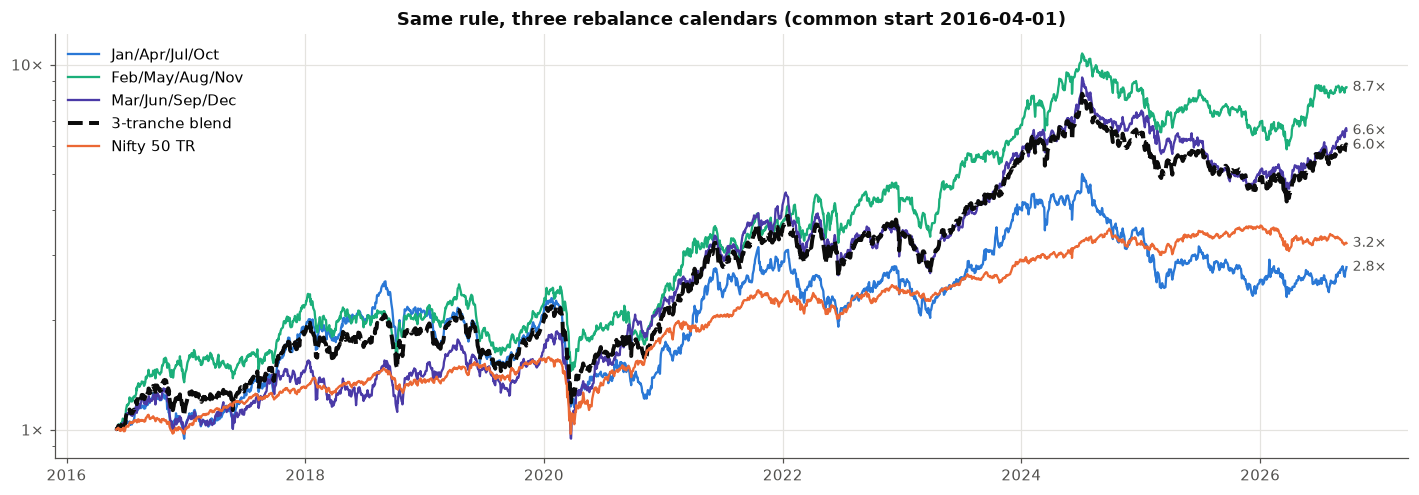

,CAGR,Ann. volatility,Sharpe (rf 6.5%),Max drawdown,Calmar,Information ratio
Jan/Apr/Jul/Oct,10.6%,29.1%,0.27,-54.9%,0.19,0.06
Feb/May/Aug/Nov,23.7%,29.3%,0.65,-45.4%,0.52,0.52
Mar/Jun/Sep/Dec,20.4%,29.7%,0.56,-51.4%,0.40,0.42
3-tranche blend,19.4%,26.8%,0.55,-49.3%,0.39,0.39
Nifty 50 TR,12.3%,16.0%,0.40,-38.3%,0.32,nan


In [23]:
sens = {"Base (3m, top 7, Jan/Apr/Jul/Oct)": M["Momentum Top 7"]}
for lbl, kw in [("Skip latest month", dict(skip=21)), ("Rebalance Feb/May/Aug/Nov", dict(months=(2, 5, 8, 11), start="2016-02-01")),
                ("Rebalance Mar/Jun/Sep/Dec", dict(months=(3, 6, 9, 12), start="2016-03-01")), ("Costs 0.5% per side", dict(cost=0.005)),
                ("No liquidity filter", dict(min_tv=0)), ("Liquidity ≥ ₹10 cr/day", dict(min_tv=10))]:
    nv, _ = backtest(**kw); r_ = nv.pct_change().fillna(0); sens[lbl] = metrics(r_, R["Nifty 50 TR"].reindex(r_.index).fillna(0))
SENS = pd.DataFrame(sens).T[["CAGR", "Ann. volatility", "Sharpe (rf 6.5%)", "Max drawdown", "Information ratio"]]
display(SENS.style.format({"CAGR": "{:.1%}", "Ann. volatility": "{:.1%}", "Max drawdown": "{:.1%}", "Sharpe (rf 6.5%)": "{:.2f}", "Information ratio": "{:.2f}"}))

start_c = "2016-04-01"
offs = {"Jan/Apr/Jul/Oct": (1, 4, 7, 10), "Feb/May/Aug/Nov": (2, 5, 8, 11), "Mar/Jun/Sep/Dec": (3, 6, 9, 12)}
navs = pd.DataFrame({k: backtest(months=m, start=start_c)[0] for k, m in offs.items()}).dropna()
navs = navs / navs.iloc[0]; navs["3-tranche blend"] = navs.mean(axis=1)
n50 = (1 + R["Nifty 50 TR"]).cumprod().reindex(navs.index); navs["Nifty 50 TR"] = n50 / n50.iloc[0]
tcol = {"Jan/Apr/Jul/Oct": COL["Momentum Top 7"], "Feb/May/Aug/Nov": COL["Nifty 500 TR"], "Mar/Jun/Sep/Dec": COL["EW Nifty 500 (PIT)"],
        "3-tranche blend": INK, "Nifty 50 TR": COL["Nifty 50 TR"]}
fig, ax = plt.subplots(figsize=(13, 4.6))
for k in navs:
    ax.plot(navs.index, navs[k], color=tcol[k], lw=2.6 if k == "3-tranche blend" else 1.5, ls="--" if k == "3-tranche blend" else "-", label=k)
    ax.annotate(f"{navs[k].iloc[-1]:.1f}×", (navs.index[-1], navs[k].iloc[-1]), xytext=(4, 0), textcoords="offset points", color=INK2, va="center", fontsize=9)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f×")); ax.legend(loc="upper left")
ax.set_title(f"Same rule, three rebalance calendars (common start {start_c})")
plt.tight_layout(); save(fig, "13_tranches"); plt.show()
TRN = pd.DataFrame({k: metrics(navs[k].pct_change().fillna(0), R["Nifty 50 TR"].reindex(navs.index).fillna(0)) for k in navs}).T
display(TRN[["CAGR", "Ann. volatility", "Sharpe (rf 6.5%)", "Max drawdown", "Calmar", "Information ratio"]]
        .style.format({"CAGR": "{:.1%}", "Ann. volatility": "{:.1%}", "Max drawdown": "{:.1%}", "Sharpe (rf 6.5%)": "{:.2f}", "Calmar": "{:.2f}", "Information ratio": "{:.2f}"}))

## 12. Conclusions

**Once survivorship bias is removed, the strategy as specified does not beat the Nifty 50.**

Net of 0.25%-per-side costs, Jan 2016 to Sep 2026, point-in-time Nifty 500:

| | Momentum Top 7 (PIT) | Nifty 50 TR | Nifty 500 TR | EW Nifty 500 (PIT) | *Same rule, today's list* |
|---|---|---|---|---|---|
| CAGR | **7.8%** | 12.2% | 13.6% | 14.2% | *31.0%* |
| ₹1 grows to | 2.2× | 3.4× | 3.8× | 4.0× | *17.2×* |
| Volatility | 29.4% | 16.1% | 16.1% | 17.8% | *29.7%* |
| Sharpe (rf 6.5%) | 0.18 | 0.39 | 0.47 | 0.47 | *0.84* |
| Max drawdown | −54.9% | −38.3% | −38.2% | −56.2% | *−47.6%* |
| Up / down capture vs Nifty 50 TR | 1.20 / 1.37 | – | – | – | *1.69 / 0.98* |

**1. The first version's 29% CAGR was almost entirely survivorship bias.**
On identical prices, switching from today's list to the real point-in-time membership cuts CAGR from 31.0% to 7.8%.
Momentum is unusually exposed to this bias because it buys whatever has just rallied hardest:
* **Graveyard effect:** 86 of the 301 real picks were stocks that later dropped out of the index (e.g. Vakrangee, Jet Airways, Religare, Dish TV, Brightcom). They averaged −1.7% per quarter with a 42% hit rate, against +6.0% and 54% for picks that survived. Removing only these names lifts CAGR to 23.2%.
* **Look-ahead effect:** today's list contains ~180 stocks that joined the index *after* their big run-up. Letting the strategy buy them early lifts CAGR to 19.6% on its own.
* Even a plain equal-weight portfolio is overstated by **10.3 points a year** (24.5% vs 14.2%) when built from today's list.

**2. Under the real universe, the 3-month top-7 rule shows no skill.**
It beats only **23%** of 2,000 random 7-stock portfolios drawn from the same universe. It lost to the Nifty 50 TR in 6 of 10 full calendar years,
had higher downside capture (1.37) than upside capture (1.20), and suffered a −55% drawdown lasting 668 trading days.

**3. Momentum isn't dead. The problem is how extreme this version is.**
Across the whole universe, the top quintile by 3-month return beats the bottom quintile (17.0% vs 10.0% a year gross).
The top 7 names, however, earn only 8.8% gross: stocks with the most extreme 3-month gains, typically +50–100%, tend to reverse.
The parameter grid (Section 11) shows the same pattern:
* 1-month lookbacks lose money outright;
* **6–12-month lookbacks with 10–15 stocks earn 18–24% CAGR at Sharpe 0.50–0.72**, above the Nifty 50 TR's 0.39;
* skipping the latest month lifts the 3-month rule to 23.0%.

This matches the academic momentum literature (roughly 12-month formation, with short-term reversal), which suggests these variants aren't just noise.

**4. A 7-stock quarterly portfolio depends heavily on its rebalance date.**
From a common April 2016 start, the identical rule makes 10.6% on the Jan/Apr/Jul/Oct calendar, 23.7% on Feb/May/Aug/Nov and 20.4% on Mar/Jun/Sep/Dec.
Splitting capital across all three (the 3-tranche blend) gives 19.4% at Sharpe 0.55. Part of the base case's weakness is therefore bad luck with the calendar.
But no calendar can be picked in advance, so the honest estimate for the rule is a wide range, not a single number.

**Caveats**
* About 20 parameter combinations were tested, so the best cells in the grid are optimistic. Any variant chosen here should be re-tested on a period it wasn't chosen on.
* **Short-term capital gains tax (20%) is not modelled.** Turnover is about 95% a quarter, so nearly all gains are short-term.
* A stock that stops trading while held is carried at its last price (no pick hit this case in the base run).
* Rights issues are adjusted only when the ratio and premium can be parsed.

**If you want to pursue momentum:** start from a **6- or 12-month lookback, skip the latest month, hold 15–25 names, and split capital into 3 monthly tranches**.
Then compare it against NSE's own **Nifty500 Momentum 50** index, which ETFs track, before trading your own version.

## Appendix: data build
The cells above read only the cached files in `data/`. The function below rebuilds any cache that's missing.
It downloads NSE bhavcopies (about 3,150 files), the corporate-actions API, index close files and the index press-release PDFs.
The Wayback snapshots used for validation are fetched from `web.archive.org/cdx`. PDF text extraction needs `pypdf`.

In [1]:
def build_missing_caches():
    import requests, zipfile, io, datetime as dt, concurrent.futures as cf
    UA = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 Chrome/120 Safari/537.36"}
    raw = f"{D}/raw"; os.makedirs(raw, exist_ok=True)
    days = pd.bdate_range("2014-01-01", CONFIG["ANCHOR_DATE"])
    if not os.path.exists(f"{D}/nse_bhav_equity.parquet"):
        def bhav(d):
            urls = ([f"https://nsearchives.nseindia.com/content/cm/BhavCopy_NSE_CM_0_0_0_{d:%Y%m%d}_F_0000.csv.zip"] if d >= pd.Timestamp("2024-07-01") else []) + \
                   [f"https://nsearchives.nseindia.com/content/historical/EQUITIES/{d:%Y}/{d:%b}".upper().replace("HTTPS://NSEARCHIVES.NSEINDIA.COM/CONTENT/HISTORICAL/EQUITIES", "https://nsearchives.nseindia.com/content/historical/EQUITIES") + f"/cm{d:%d}{d.strftime('%b').upper()}{d:%Y}bhav.csv.zip"]
            for u in urls:
                r = requests.get(u, headers=UA, timeout=40)
                if r.status_code == 200 and r.content[:2] == b"PK":
                    z = zipfile.ZipFile(io.BytesIO(r.content)); df = pd.read_csv(z.open(z.namelist()[0]))
                    df = df.rename(columns={"TckrSymb": "symbol", "SctySrs": "series", "OpnPric": "open", "ClsPric": "close", "PrvsClsgPric": "prevclose", "TtlTrfVal": "value", "ISIN": "isin",
                                            "SYMBOL": "symbol", "SERIES": "series", "OPEN": "open", "CLOSE": "close", "PREVCLOSE": "prevclose", "TOTTRDVAL": "value"})
                    return df[df.series.isin(["EQ", "BE", "BZ"])][["symbol", "series", "isin", "open", "close", "prevclose", "value"]].assign(date=d)
        with cf.ThreadPoolExecutor(4) as ex: parts = [p for p in ex.map(bhav, days) if p is not None]
        pd.concat(parts, ignore_index=True).to_parquet(f"{D}/nse_bhav_equity.parquet")
    if not os.path.exists(f"{D}/nse_corporate_actions.csv"):
        s = requests.Session(); s.headers.update({**UA, "Accept": "application/json", "Referer": "https://www.nseindia.com/companies-listing/corporate-filings-actions"})
        s.get("https://www.nseindia.com/", timeout=30); out = []
        for y in range(2014, pd.Timestamp(CONFIG["ANCHOR_DATE"]).year + 1):
            for a_, b_ in [("01-01", "30-06"), ("01-07", "31-12")]:
                out += s.get(f"https://www.nseindia.com/api/corporates-corporateActions?index=equities&from_date={a_}-{y}&to_date={b_}-{y}", timeout=90).json()
        pd.DataFrame(out).drop_duplicates().to_csv(f"{D}/nse_corporate_actions.csv", index=False)
    if not os.path.exists(f"{D}/nse_indices.parquet"):
        rows = []
        for d in days:
            r = requests.get(f"https://nsearchives.nseindia.com/content/indices/ind_close_all_{d:%d%m%Y}.csv", headers=UA, timeout=40)
            if r.status_code == 200 and r.content[:5] == b"Index":
                df = pd.read_csv(io.BytesIO(r.content)); df.columns = [c.strip() for c in df.columns]; rows.append(df.assign(date=d))
        I = pd.concat(rows); I["name"] = I["Index Name"].str.strip().str.upper().replace({"CNX NIFTY": "NIFTY 50", "CNX 500": "NIFTY 500"})
        I = I[I.name.isin(["NIFTY 50", "NIFTY 500", "NIFTY500 EQUAL WEIGHT", "NIFTY500 MOMENTUM 50"])]
        I["close"] = pd.to_numeric(I["Closing Index Value"], errors="coerce"); I["dy"] = pd.to_numeric(I["Div Yield"], errors="coerce")
        X = I.pivot_table(index="date", columns="name", values=["close", "dy"]); X.columns = [f"{a}|{b}" for a, b in X.columns]; X.to_parquet(f"{D}/nse_indices.parquet")
    txt = f"{D}/press_releases_txt"
    if not os.path.isdir(txt) or not os.listdir(txt):
        import pypdf, logging; logging.disable(logging.WARNING); os.makedirs(txt, exist_ok=True)
        for d in pd.date_range("2014-12-01", CONFIG["ANCHOR_DATE"]):
            for sfx in ["", "_1", "_2", "_3"]:
                r = requests.get(f"https://www.niftyindices.com/Press_Release/ind_prs{d:%d%m%Y}{sfx}.pdf", headers=UA, timeout=40)
                if "pdf" not in r.headers.get("content-type", ""):
                    if sfx: break
                    continue
                t = "\n".join((p.extract_text() or "") for p in pypdf.PdfReader(io.BytesIO(r.content)).pages)
                open(f"{txt}/ind_prs{d:%d%m%Y}{sfx}.txt", "w").write(t)
    print("caches present:", sorted(os.listdir(D)))
# build_missing_caches()   # uncomment to (re)build anything missing from data/